
# MyoLab-AI — Day 32: Leakage-Safe Classical Baseline Modeling

Notebook này là **standalone**: mở trong một notebook/Colab mới và chạy từ đầu đến cuối, không phụ thuộc notebook ETL hoặc module trong GitHub repo.

## Input bắt buộc

```text
/content/drive/MyDrive/MyoLab-AI-data/
└── mendeley-4channel-hand-gesture-v2/
    └── outputs/
        └── day31-mendeley-primary-fall14.npz
```

NPZ phải là artifact Day 31 đã PASS, gồm 40 subjects, 42 feature columns, subject split cố định `32 train / 8 validation`, cùng các feature arm:

- `F-TD8`: 24 chiều.
- `F-SP6`: 18 chiều.
- `F-ALL14`: 42 chiều.
- `F-NO-MOMENTS12`: 36 chiều.

## Logic modeling được khóa

1. **Không random split theo window.**
2. Cross-validation chỉ chạy trong 32 training subjects bằng `StratifiedGroupKFold`.
3. Mọi scaler nằm trong `sklearn.pipeline.Pipeline`, nên chỉ fit trên training fold.
4. Model/feature arm được chọn bằng **repetition-level macro-F1 trong grouped CV**.
5. Frozen validation 8 subjects chỉ được đánh giá **một lần sau khi lựa chọn hoàn tất**.
6. Không có test set, không pooled training, không hyperparameter tuning trên validation.
7. Xuất predictions và evidence để Day 33 thực hiện repetition/subject-level error analysis.

## Output chính

```text
day32-baseline-v1/
├── day32-cv-leaderboard.csv
├── day32-cv-fold-metrics.csv
├── day32-selected-oof-window-predictions.csv.gz
├── day32-selected-oof-repetition-predictions.csv
├── day32-validation-window-predictions.csv.gz
├── day32-validation-repetition-predictions.csv
├── day32-validation-subject-metrics.csv
├── day32-selected-model.joblib
├── day32-baseline-evidence.json
├── day32-final-gate.json
└── day32-baseline-handoff.zip
```

> **Lưu ý:** Đây là engineering/research baseline, không phải clinical model và không được dùng để đưa ra quyết định điều trị.


## CELL 1 — Environment setup

In [1]:

# === CELL 1: Environment setup ===
from __future__ import annotations

import importlib.util
import subprocess
import sys

_REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "joblib": "joblib",
}

_missing = [
    pip_name
    for import_name, pip_name in _REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if _missing:
    print("[INFO] Installing missing packages:", _missing)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *_missing]
    )

print("[PASS] Required Python packages are available.")


[PASS] Required Python packages are available.


## CELL 2 — Imports, Drive mount, configuration and governance

In [2]:

# === CELL 2: Imports, Drive mount, configuration and governance ===
from __future__ import annotations

import csv
import gzip
import hashlib
import json
import math
import os
import platform
import shutil
import time
import warnings
import zipfile
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


# -----------------------------------------------------------------------------
# 1. Environment
# -----------------------------------------------------------------------------

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive, files  # type: ignore

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")


# -----------------------------------------------------------------------------
# 2. Day 32 authorization and immutable safety flags
# -----------------------------------------------------------------------------

DAY32_MODEL_FITTING_AUTHORIZED = True
OPEN_FROZEN_VALIDATION_AFTER_SELECTION = True

HYPERPARAMETER_TUNING_ALLOWED = False
TEST_SET_OPENED = False
POOLED_TRAINING_ALLOWED = False
CLINICAL_USE_ALLOWED = False

assert DAY32_MODEL_FITTING_AUTHORIZED is True
assert OPEN_FROZEN_VALIDATION_AFTER_SELECTION is True
assert HYPERPARAMETER_TUNING_ALLOWED is False
assert TEST_SET_OPENED is False
assert POOLED_TRAINING_ALLOWED is False
assert CLINICAL_USE_ALLOWED is False


# -----------------------------------------------------------------------------
# 3. Run configuration
# -----------------------------------------------------------------------------

RUN_ID = "day32-baseline-v1"
RANDOM_SEED = 3201
N_SPLITS = 5
N_JOBS = -1

RUN_OPTIONAL_MODELS = False
FORCE_RECOMPUTE_CV = False
DOWNLOAD_HANDOFF_TO_BROWSER = False

# Chỉ dùng để kiểm tra notebook nhanh. Không được dùng làm kết quả Day 32 chính thức.
QUICK_SMOKE_TEST = False

# Có thể gán đường dẫn khác trước khi chạy cell này hoặc dùng biến môi trường.
NPZ_PATH_OVERRIDE = os.environ.get("DAY31_NPZ_PATH", "").strip()

DATASET_SLUG = "mendeley-4channel-hand-gesture-v2"

DRIVE_DATASET_ROOT = (
    Path("/content/drive/MyDrive/MyoLab-AI-data") / DATASET_SLUG
)

DEFAULT_DRIVE_NPZ = (
    DRIVE_DATASET_ROOT
    / "outputs"
    / "day31-mendeley-primary-fall14.npz"
)

DEFAULT_LOCAL_NPZ = (
    Path.cwd() / "day31-mendeley-primary-fall14.npz"
)

if IN_COLAB:
    RUNTIME_ROOT = (
        Path("/content/data")
        / DATASET_SLUG
        / "day32-baseline"
        / RUN_ID
    )
else:
    RUNTIME_ROOT = (
        Path.cwd()
        / ".day32-runtime"
        / DATASET_SLUG
        / RUN_ID
    )

if Path("/content/drive/MyDrive").exists():
    PERSIST_ROOT = (
        DRIVE_DATASET_ROOT
        / "outputs"
        / "day32-baseline"
        / RUN_ID
    )
else:
    PERSIST_ROOT = (
        Path.cwd()
        / "day32-baseline-output"
        / RUN_ID
    )

RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)
PERSIST_ROOT.mkdir(parents=True, exist_ok=True)

if QUICK_SMOKE_TEST:
    N_SPLITS = 3

np.random.seed(RANDOM_SEED)

print("=" * 88)
print("[CELL 2] DAY 32 CONFIGURATION")
print("=" * 88)
print(f"IN_COLAB                    : {IN_COLAB}")
print(f"Python                      : {platform.python_version()}")
print(f"NumPy                       : {np.__version__}")
print(f"Pandas                      : {pd.__version__}")
print(f"scikit-learn                : {sklearn.__version__}")
print(f"Runtime output              : {RUNTIME_ROOT}")
print(f"Persistent output           : {PERSIST_ROOT}")
print(f"Grouped CV folds            : {N_SPLITS}")
print(f"Optional models             : {RUN_OPTIONAL_MODELS}")
print(f"Quick smoke test            : {QUICK_SMOKE_TEST}")
print(f"Model fitting authorized    : {DAY32_MODEL_FITTING_AUTHORIZED}")
print(f"Hyperparameter tuning       : {HYPERPARAMETER_TUNING_ALLOWED}")
print(f"Test set opened             : {TEST_SET_OPENED}")
print(f"Clinical use allowed        : {CLINICAL_USE_ALLOWED}")
print("[PASS] Governance and paths initialized.")


Mounted at /content/drive
[CELL 2] DAY 32 CONFIGURATION
IN_COLAB                    : True
Python                      : 3.12.13
NumPy                       : 2.0.2
Pandas                      : 2.2.2
scikit-learn                : 1.6.1
Runtime output              : /content/data/mendeley-4channel-hand-gesture-v2/day32-baseline/day32-baseline-v1
Persistent output           : /content/drive/MyDrive/MyoLab-AI-data/mendeley-4channel-hand-gesture-v2/outputs/day32-baseline/day32-baseline-v1
Grouped CV folds            : 5
Optional models             : False
Quick smoke test            : False
Model fitting authorized    : True
Hyperparameter tuning       : False
Test set opened             : False
Clinical use allowed        : False
[PASS] Governance and paths initialized.


## CELL 3 — Common helpers

In [3]:

# === CELL 3: Common helpers ===

def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_obj:
        while True:
            chunk = file_obj.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def json_safe(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, np.ndarray):
        return json_safe(value.tolist())
    if isinstance(value, np.generic):
        return json_safe(value.item())
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


def write_json_atomic(payload: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".part")
    temporary.write_text(
        json.dumps(
            json_safe(payload),
            ensure_ascii=False,
            indent=2,
            sort_keys=False,
        )
        + "\n",
        encoding="utf-8",
    )
    temporary.replace(path)


def copy_atomic(source: Path, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_suffix(destination.suffix + ".part")
    temporary.unlink(missing_ok=True)
    shutil.copy2(source, temporary)
    if temporary.stat().st_size != source.stat().st_size:
        temporary.unlink(missing_ok=True)
        raise RuntimeError(
            f"Atomic copy size mismatch: {source} -> {destination}"
        )
    temporary.replace(destination)


def persist_artifact(runtime_path: Path) -> Path:
    persistent_path = PERSIST_ROOT / runtime_path.name
    copy_atomic(runtime_path, persistent_path)
    return persistent_path


def write_dataframe(
    dataframe: pd.DataFrame,
    path: Path,
    *,
    index: bool = False,
) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".part")

    if path.name.endswith(".csv.gz"):
        dataframe.to_csv(
            temporary,
            index=index,
            compression="gzip",
        )
    else:
        dataframe.to_csv(temporary, index=index)

    temporary.replace(path)
    return path


def scalar_text(npz, key: str, default: str = "") -> str:
    if key not in npz.files:
        return default
    value = np.asarray(npz[key])
    if value.size != 1:
        raise RuntimeError(f"Expected scalar NPZ key: {key}")
    return str(value.reshape(-1)[0])


def scalar_bool(npz, key: str, default: bool | None = None) -> bool | None:
    if key not in npz.files:
        return default
    value = np.asarray(npz[key])
    if value.size != 1:
        raise RuntimeError(f"Expected scalar boolean NPZ key: {key}")
    return bool(value.reshape(-1)[0])


def subject_sort_key(subject_id: str):
    text = str(subject_id)
    return (0, int(text)) if text.isdigit() else (1, text)


def class_count_dict(labels: np.ndarray) -> dict[str, int]:
    unique, counts = np.unique(labels, return_counts=True)
    return {
        str(label): int(count)
        for label, count in zip(unique, counts)
    }


def mean_std(values: Iterable[float]) -> tuple[float | None, float | None]:
    clean = [
        float(value)
        for value in values
        if value is not None and math.isfinite(float(value))
    ]
    if not clean:
        return None, None
    return float(np.mean(clean)), float(np.std(clean, ddof=0))


def classification_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, y_pred)
        ),
        "macro_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "weighted_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
        ),
        "macro_precision": float(
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_recall": float(
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "cohen_kappa": float(
            cohen_kappa_score(y_true, y_pred)
        ),
    }


def deterministic_majority_vote(
    labels: np.ndarray,
    class_order: np.ndarray,
) -> tuple[str, float]:
    label_to_index = {
        str(label): index
        for index, label in enumerate(class_order.tolist())
    }
    counts = np.zeros(len(class_order), dtype=np.int64)

    for label in labels:
        key = str(label)
        if key not in label_to_index:
            raise RuntimeError(f"Unknown predicted class: {key}")
        counts[label_to_index[key]] += 1

    winner_index = int(np.argmax(counts))
    vote_fraction = float(counts[winner_index] / counts.sum())
    return str(class_order[winner_index]), vote_fraction


def aggregate_repetition_predictions(
    *,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    repetition_ids: np.ndarray,
    subject_ids: np.ndarray,
    class_order: np.ndarray,
    fold_ids: np.ndarray | None = None,
) -> pd.DataFrame:
    frame = pd.DataFrame(
        {
            "subject_id": subject_ids.astype(str),
            "repetition_id": repetition_ids.astype(str),
            "y_true": y_true.astype(str),
            "y_pred": y_pred.astype(str),
        }
    )

    if fold_ids is not None:
        frame["fold_id"] = fold_ids.astype(int)

    rows: list[dict[str, Any]] = []

    for repetition_id, group in frame.groupby(
        "repetition_id",
        sort=False,
    ):
        true_labels = group["y_true"].unique()
        subjects = group["subject_id"].unique()

        if len(true_labels) != 1:
            raise RuntimeError(
                f"Repetition {repetition_id} has multiple true labels: "
                f"{true_labels.tolist()}"
            )

        if len(subjects) != 1:
            raise RuntimeError(
                f"Repetition {repetition_id} maps to multiple subjects."
            )

        if "fold_id" in group.columns and group["fold_id"].nunique() != 1:
            raise RuntimeError(
                f"Repetition {repetition_id} spans multiple CV folds."
            )

        predicted_label, vote_fraction = deterministic_majority_vote(
            group["y_pred"].to_numpy(),
            class_order,
        )

        row = {
            "subject_id": str(subjects[0]),
            "repetition_id": str(repetition_id),
            "y_true": str(true_labels[0]),
            "y_pred": predicted_label,
            "n_windows": int(len(group)),
            "vote_fraction": vote_fraction,
        }

        if "fold_id" in group.columns:
            row["fold_id"] = int(group["fold_id"].iloc[0])

        rows.append(row)

    return pd.DataFrame(rows)


def subject_metric_table(
    repetition_predictions: pd.DataFrame,
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    for subject_id, group in repetition_predictions.groupby(
        "subject_id",
        sort=False,
    ):
        metrics = classification_metrics(
            group["y_true"].to_numpy(),
            group["y_pred"].to_numpy(),
        )
        rows.append(
            {
                "subject_id": str(subject_id),
                "n_repetitions": int(len(group)),
                **metrics,
            }
        )

    return pd.DataFrame(rows).sort_values(
        "subject_id",
        key=lambda series: series.map(subject_sort_key),
    )


def prediction_confidence(
    estimator,
    X_matrix: np.ndarray,
) -> tuple[np.ndarray, str]:
    if hasattr(estimator, "predict_proba"):
        probabilities = estimator.predict_proba(X_matrix)
        return (
            np.max(probabilities, axis=1).astype(np.float64),
            "max_predict_proba",
        )

    if hasattr(estimator, "decision_function"):
        scores = np.asarray(estimator.decision_function(X_matrix))
        if scores.ndim == 1:
            confidence = np.abs(scores)
        else:
            ordered = np.sort(scores, axis=1)
            confidence = ordered[:, -1] - ordered[:, -2]
        return confidence.astype(np.float64), "decision_margin"

    return (
        np.full(X_matrix.shape[0], np.nan, dtype=np.float64),
        "unavailable",
    )


print("[PASS] Common helpers loaded.")


[PASS] Common helpers loaded.


## CELL 4 — Locate, load and validate the Day 31 NPZ

In [5]:
# === AUDIT: Investigate missing gesture-repetition record ===

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd


# ------------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------------

DRIVE_DATASET_ROOT = Path(
    "/content/drive/MyDrive/MyoLab-AI-data/"
    "mendeley-4channel-hand-gesture-v2"
)

EXCLUSION_CANDIDATES = [
    DRIVE_DATASET_ROOT
    / "manifests"
    / "day31-feature-exclusion-report.csv",

    DRIVE_DATASET_ROOT
    / "outputs"
    / "day31-feature-exclusion-report.csv",

    Path(
        "/content/data/mendeley-4channel-hand-gesture-v2/"
        "manifests/day31-feature-exclusion-report.csv"
    ),
]

WINDOW_INDEX_CANDIDATES = [
    DRIVE_DATASET_ROOT
    / "manifests"
    / "window-index-mendeley-primary.csv.gz",

    DRIVE_DATASET_ROOT
    / "outputs"
    / "window-index-mendeley-primary.csv.gz",

    Path(
        "/content/data/mendeley-4channel-hand-gesture-v2/"
        "indexes/window-index-mendeley-primary.csv.gz"
    ),
]


def first_existing(paths):
    return next((path for path in paths if path.exists()), None)


exclusion_path = first_existing(EXCLUSION_CANDIDATES)
window_index_path = first_existing(WINDOW_INDEX_CANDIDATES)


# ------------------------------------------------------------------
# 2. Observe NPZ repetition population
# ------------------------------------------------------------------

observed_repetition_ids = np.unique(repetition_ids)
observed_count = len(observed_repetition_ids)

print("=" * 80)
print("[DAY32 INPUT AUDIT]")
print("=" * 80)

print(f"Observed repetition count : {observed_count}")
print(f"Expected target count     : 800")
print(f"Difference                : {800 - observed_count}")


# ------------------------------------------------------------------
# 3. Basic distribution audit
# ------------------------------------------------------------------

npz_frame = pd.DataFrame(
    {
        "repetition_id": repetition_ids,
        "subject_id": subject_ids,
        "label": y,
        "split_name": split_names,
        "record_id": record_ids,
    }
)

repetition_summary = (
    npz_frame
    .groupby("repetition_id", as_index=False)
    .agg(
        subject_id=("subject_id", "first"),
        label=("label", "first"),
        split_name=("split_name", "first"),
        record_id=("record_id", "first"),
        valid_window_count=("repetition_id", "size"),
    )
)

print("\n[VALID WINDOWS PER REPETITION]")
print(
    repetition_summary["valid_window_count"]
    .describe()
    .to_string()
)

print("\n[LOWEST VALID-WINDOW REPETITIONS]")
display(
    repetition_summary
    .sort_values(
        ["valid_window_count", "subject_id", "label"]
    )
    .head(20)
)


# ------------------------------------------------------------------
# 4. Read exclusion report
# ------------------------------------------------------------------

if exclusion_path is None:
    print(
        "\n[WARN] Không tìm thấy exclusion report. "
        "Chưa thể chứng minh repetition bị mất do QC exclusion."
    )

else:
    print(f"\n[INFO] Exclusion report: {exclusion_path}")

    exclusion_df = pd.read_csv(
        exclusion_path,
        dtype={
            "subject_id": str,
            "record_id": str,
            "repetition_id": str,
            "window_id": str,
        },
    )

    print(f"Excluded windows: {len(exclusion_df)}")

    excluded_by_rep = (
        exclusion_df
        .groupby("repetition_id", as_index=False)
        .agg(
            subject_id=("subject_id", "first"),
            record_id=("record_id", "first"),
            canonical_label=("canonical_label", "first"),
            partition=("partition", "first"),
            excluded_window_count=("window_id", "nunique"),
            reason_codes=(
                "reason_code",
                lambda values: ";".join(
                    sorted(set(values.astype(str)))
                ),
            ),
            invalid_primary_channels=(
                "invalid_primary_channels",
                lambda values: ";".join(
                    sorted(
                        set(
                            value
                            for value in values.astype(str)
                            if value and value != "nan"
                        )
                    )
                ),
            ),
            qc_flags=(
                "qc_flags",
                lambda values: ";".join(
                    sorted(
                        set(
                            value
                            for value in values.astype(str)
                            if value and value != "nan"
                        )
                    )
                ),
            ),
        )
    )

    fully_excluded = excluded_by_rep[
        excluded_by_rep["excluded_window_count"] == 59
    ].copy()

    print("\n[FULLY EXCLUDED REPETITIONS]")
    print(f"Count: {len(fully_excluded)}")

    if len(fully_excluded):
        display(fully_excluded)

    partially_excluded = excluded_by_rep[
        excluded_by_rep["excluded_window_count"] < 59
    ].copy()

    print("\n[PARTIALLY EXCLUDED REPETITIONS]")
    print(f"Count: {len(partially_excluded)}")

    if len(partially_excluded):
        display(
            partially_excluded.sort_values(
                "excluded_window_count",
                ascending=False,
            ).head(20)
        )


# ------------------------------------------------------------------
# 5. Compare with complete Day31 window index
# ------------------------------------------------------------------

if window_index_path is None:
    print(
        "\n[WARN] Không tìm thấy full window index. "
        "Có thể audit exclusion nhưng chưa reconstruct được "
        "đầy đủ tập 800 repetition dự kiến."
    )

else:
    print(f"\n[INFO] Window index: {window_index_path}")

    window_index_df = pd.read_csv(
        window_index_path,
        compression="infer",
        dtype={
            "subject_id": str,
            "record_id": str,
            "repetition_id": str,
            "window_id": str,
        },
    )

    expected_repetition_ids = set(
        window_index_df["repetition_id"].unique()
    )

    observed_repetition_set = set(
        observed_repetition_ids.tolist()
    )

    missing_repetition_ids = sorted(
        expected_repetition_ids - observed_repetition_set
    )

    unexpected_repetition_ids = sorted(
        observed_repetition_set - expected_repetition_ids
    )

    print("\n[REPETITION SET COMPARISON]")
    print(
        f"Window-index repetitions : "
        f"{len(expected_repetition_ids)}"
    )
    print(
        f"NPZ repetitions          : "
        f"{len(observed_repetition_set)}"
    )
    print(
        f"Missing from NPZ          : "
        f"{len(missing_repetition_ids)}"
    )
    print(
        f"Unexpected in NPZ         : "
        f"{len(unexpected_repetition_ids)}"
    )

    if missing_repetition_ids:
        missing_rows = (
            window_index_df[
                window_index_df["repetition_id"].isin(
                    missing_repetition_ids
                )
            ]
            .groupby("repetition_id", as_index=False)
            .agg(
                subject_id=("subject_id", "first"),
                record_id=("record_id", "first"),
                canonical_label=("canonical_label", "first"),
                partition=("partition", "first"),
                expected_window_count=("window_id", "nunique"),
            )
        )

        print("\n[MISSING REPETITION DETAILS]")
        display(missing_rows)

        if exclusion_path is not None:
            missing_exclusion = (
                exclusion_df[
                    exclusion_df["repetition_id"].isin(
                        missing_repetition_ids
                    )
                ]
                .groupby("repetition_id", as_index=False)
                .agg(
                    excluded_window_count=(
                        "window_id",
                        "nunique",
                    ),
                    reason_codes=(
                        "reason_code",
                        lambda values: ";".join(
                            sorted(set(values.astype(str)))
                        ),
                    ),
                    invalid_primary_channels=(
                        "invalid_primary_channels",
                        lambda values: ";".join(
                            sorted(set(values.astype(str)))
                        ),
                    ),
                    qc_flags=(
                        "qc_flags",
                        lambda values: ";".join(
                            sorted(set(values.astype(str)))
                        ),
                    ),
                )
            )

            audit_join = missing_rows.merge(
                missing_exclusion,
                on="repetition_id",
                how="left",
            )

            print("\n[MISSING REPETITION + EXCLUSION EVIDENCE]")
            display(audit_join)

            fully_explained = (
                audit_join["excluded_window_count"]
                .fillna(-1)
                .astype(int)
                .eq(
                    audit_join["expected_window_count"].astype(int)
                )
                .all()
            )

            print(
                "\nFully explained by exclusions: "
                f"{fully_explained}"
            )

[DAY32 INPUT AUDIT]
Observed repetition count : 799
Expected target count     : 800
Difference                : 1

[VALID WINDOWS PER REPETITION]
count    799.000000
mean      58.944931
std        1.556608
min       15.000000
25%       59.000000
50%       59.000000
75%       59.000000
max       59.000000

[LOWEST VALID-WINDOW REPETITIONS]


,repetition_id,subject_id,label,split_name,record_id,valid_window_count
57,mendeley-S003-wrist_flexion-R04,3,wrist_flexion,train,mendeley-S003-R04-G02-wrist_flexion,15
0,mendeley-S001-grip-R01,1,hand_close,train,mendeley-S001-R01-G05-grip,59
1,mendeley-S001-grip-R02,1,hand_close,train,mendeley-S001-R02-G05-grip,59
2,mendeley-S001-grip-R03,1,hand_close,train,mendeley-S001-R03-G05-grip,59
3,mendeley-S001-grip-R04,1,hand_close,train,mendeley-S001-R04-G05-grip,59
4,mendeley-S001-grip-R05,1,hand_close,train,mendeley-S001-R05-G05-grip,59
5,mendeley-S001-rest-R01,1,rest,train,mendeley-S001-R01-G00-rest,59
6,mendeley-S001-rest-R02,1,rest,train,mendeley-S001-R02-G00-rest,59
7,mendeley-S001-rest-R03,1,rest,train,mendeley-S001-R03-G00-rest,59
8,mendeley-S001-rest-R04,1,rest,train,mendeley-S001-R04-G00-rest,59



[INFO] Exclusion report: /content/drive/MyDrive/MyoLab-AI-data/mendeley-4channel-hand-gesture-v2/manifests/day31-feature-exclusion-report.csv
Excluded windows: 103

[FULLY EXCLUDED REPETITIONS]
Count: 1


,repetition_id,subject_id,record_id,canonical_label,partition,excluded_window_count,reason_codes,invalid_primary_channels,qc_flags
0,mendeley-S003-rest-R04,3,mendeley-S003-R04-G00-rest,rest,train,59,NONFINITE_PRIMARY_FEATURE,CH2,constant_window;feature_nonfinite;zero_power_w...



[PARTIALLY EXCLUDED REPETITIONS]
Count: 1


...


[INFO] Window index: /content/drive/MyDrive/MyoLab-AI-data/mendeley-4channel-hand-gesture-v2/manifests/window-index-mendeley-primary.csv.gz

[REPETITION SET COMPARISON]
Window-index repetitions : 800
NPZ repetitions          : 799
Missing from NPZ          : 1
Unexpected in NPZ         : 0

[MISSING REPETITION DETAILS]


,repetition_id,subject_id,record_id,canonical_label,partition,expected_window_count
0,mendeley-S003-rest-R04,3,mendeley-S003-R04-G00-rest,rest,train,59



[MISSING REPETITION + EXCLUSION EVIDENCE]


,repetition_id,subject_id,record_id,canonical_label,partition,expected_window_count,excluded_window_count,reason_codes,invalid_primary_channels,qc_flags
0,mendeley-S003-rest-R04,3,mendeley-S003-R04-G00-rest,rest,train,59,59,NONFINITE_PRIMARY_FEATURE,CH2,constant_window;feature_nonfinite;zero_power_w...



Fully explained by exclusions: True


In [9]:
# ============================================================
# CELL 4 PATCH: Repetition population and exclusion provenance gate
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Frozen Day31 protocol contract
# ------------------------------------------------------------

PROTOCOL_SUBJECT_COUNT = 40
PROTOCOL_GESTURE_COUNT = 4
PROTOCOL_REPETITIONS_PER_GESTURE = 5

PROTOCOL_EXPECTED_REPETITIONS = (
    PROTOCOL_SUBJECT_COUNT
    * PROTOCOL_GESTURE_COUNT
    * PROTOCOL_REPETITIONS_PER_GESTURE
)

EXPECTED_WINDOWS_PER_REPETITION = 59

assert PROTOCOL_EXPECTED_REPETITIONS == 800


# ------------------------------------------------------------
# 2. Day31 artifact paths
# ------------------------------------------------------------

DATASET_ROOT = Path(
    "/content/drive/MyDrive/MyoLab-AI-data/"
    "mendeley-4channel-hand-gesture-v2"
)

EXCLUSION_REPORT_PATH = (
    DATASET_ROOT
    / "manifests"
    / "day31-feature-exclusion-report.csv"
)

WINDOW_INDEX_PATH = (
    DATASET_ROOT
    / "manifests"
    / "window-index-mendeley-primary.csv.gz"
)


for required_path in [
    EXCLUSION_REPORT_PATH,
    WINDOW_INDEX_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            "Thiếu artifact cần thiết để xác minh exclusion:\n"
            f"{required_path}"
        )


# ------------------------------------------------------------
# 3. Observe modeling population
# ------------------------------------------------------------

observed_repetition_set = set(
    np.unique(repetition_ids).astype(str).tolist()
)

observed_repetition_count = len(observed_repetition_set)


# ------------------------------------------------------------
# 4. Load Day31 complete window population
# ------------------------------------------------------------

window_index_df = pd.read_csv(
    WINDOW_INDEX_PATH,
    compression="infer",
    dtype={
        "repetition_id": str,
        "window_id": str,
        "subject_id": str,
        "record_id": str,
        "canonical_label": str,
        "partition": str,
    },
)

required_window_columns = {
    "repetition_id",
    "window_id",
    "subject_id",
    "record_id",
    "canonical_label",
    "partition",
}

missing_window_columns = (
    required_window_columns - set(window_index_df.columns)
)

if missing_window_columns:
    raise RuntimeError(
        "Window index thiếu các cột bắt buộc: "
        f"{sorted(missing_window_columns)}"
    )


expected_repetition_set = set(
    window_index_df["repetition_id"].unique().tolist()
)

if len(expected_repetition_set) != PROTOCOL_EXPECTED_REPETITIONS:
    raise RuntimeError(
        "DAY31 PROTOCOL POPULATION GATE FAILED.\n"
        f"Expected repetitions: {PROTOCOL_EXPECTED_REPETITIONS}\n"
        f"Window-index repetitions: {len(expected_repetition_set)}"
    )


# ------------------------------------------------------------
# 5. Load Day31 exclusion evidence
# ------------------------------------------------------------

exclusion_df = pd.read_csv(
    EXCLUSION_REPORT_PATH,
    dtype={
        "repetition_id": str,
        "window_id": str,
        "subject_id": str,
        "record_id": str,
        "canonical_label": str,
        "partition": str,
        "reason_code": str,
        "invalid_primary_channels": str,
        "qc_flags": str,
    },
)

required_exclusion_columns = {
    "repetition_id",
    "window_id",
    "subject_id",
    "record_id",
    "canonical_label",
    "partition",
    "reason_code",
}

missing_exclusion_columns = (
    required_exclusion_columns - set(exclusion_df.columns)
)

if missing_exclusion_columns:
    raise RuntimeError(
        "Exclusion report thiếu các cột bắt buộc: "
        f"{sorted(missing_exclusion_columns)}"
    )


# ------------------------------------------------------------
# 6. Compare expected and observed repetition sets
# ------------------------------------------------------------

missing_repetition_ids = sorted(
    expected_repetition_set - observed_repetition_set
)

unexpected_repetition_ids = sorted(
    observed_repetition_set - expected_repetition_set
)

if unexpected_repetition_ids:
    raise RuntimeError(
        "NPZ chứa repetition ID không tồn tại trong "
        "Day31 window index:\n"
        + "\n".join(unexpected_repetition_ids)
    )


# ------------------------------------------------------------
# 7. Build expected and excluded window counts
# ------------------------------------------------------------

expected_windows_by_repetition = (
    window_index_df
    .groupby("repetition_id")["window_id"]
    .nunique()
)

excluded_windows_by_repetition = (
    exclusion_df
    .groupby("repetition_id")["window_id"]
    .nunique()
)

exclusion_details = (
    exclusion_df
    .groupby("repetition_id", as_index=False)
    .agg(
        subject_id=("subject_id", "first"),
        record_id=("record_id", "first"),
        canonical_label=("canonical_label", "first"),
        partition=("partition", "first"),
        excluded_window_count=("window_id", "nunique"),
        reason_codes=(
            "reason_code",
            lambda values: sorted(
                set(values.dropna().astype(str))
            ),
        ),
        invalid_primary_channels=(
            "invalid_primary_channels",
            lambda values: sorted(
                set(
                    value
                    for value in values.dropna().astype(str)
                    if value
                )
            ),
        ),
        qc_flags=(
            "qc_flags",
            lambda values: sorted(
                set(
                    value
                    for value in values.dropna().astype(str)
                    if value
                )
            ),
        ),
    )
)


# ------------------------------------------------------------
# 8. Validate every missing repetition
# ------------------------------------------------------------

fully_excluded_records = []
unexplained_missing_records = []

for repetition_id in missing_repetition_ids:
    expected_window_count = int(
        expected_windows_by_repetition.get(
            repetition_id,
            0,
        )
    )

    excluded_window_count = int(
        excluded_windows_by_repetition.get(
            repetition_id,
            0,
        )
    )

    metadata_rows = window_index_df[
        window_index_df["repetition_id"] == repetition_id
    ]

    if metadata_rows.empty:
        unexplained_missing_records.append(
            {
                "repetition_id": repetition_id,
                "reason": "missing_from_window_index_metadata",
            }
        )
        continue

    metadata = metadata_rows.iloc[0]

    detail_rows = exclusion_details[
        exclusion_details["repetition_id"] == repetition_id
    ]

    detail = (
        detail_rows.iloc[0].to_dict()
        if not detail_rows.empty
        else {}
    )

    audit_record = {
        "repetition_id": repetition_id,
        "subject_id": str(metadata["subject_id"]),
        "record_id": str(metadata["record_id"]),
        "canonical_label": str(
            metadata["canonical_label"]
        ),
        "partition": str(metadata["partition"]),
        "expected_window_count": expected_window_count,
        "excluded_window_count": excluded_window_count,
        "reason_codes": detail.get(
            "reason_codes",
            [],
        ),
        "invalid_primary_channels": detail.get(
            "invalid_primary_channels",
            [],
        ),
        "qc_flags": detail.get(
            "qc_flags",
            [],
        ),
    }

    if expected_window_count != EXPECTED_WINDOWS_PER_REPETITION:
        audit_record["failure_reason"] = (
            "unexpected_protocol_window_count"
        )
        unexplained_missing_records.append(audit_record)
        continue

    if excluded_window_count != expected_window_count:
        audit_record["failure_reason"] = (
            "missing_not_fully_explained_by_exclusions"
        )
        unexplained_missing_records.append(audit_record)
        continue

    fully_excluded_records.append(audit_record)


if unexplained_missing_records:
    raise RuntimeError(
        "Có repetition bị thiếu nhưng không được giải thích "
        "đầy đủ bởi Day31 exclusion evidence:\n"
        + json.dumps(
            unexplained_missing_records,
            ensure_ascii=False,
            indent=2,
        )
    )


# ------------------------------------------------------------
# 9. Identify partially excluded repetitions
# ------------------------------------------------------------

partial_exclusions_df = exclusion_details[
    exclusion_details["excluded_window_count"].between(
        1,
        EXPECTED_WINDOWS_PER_REPETITION - 1,
    )
].copy()

partially_excluded_records = (
    partial_exclusions_df.to_dict(orient="records")
)


# ------------------------------------------------------------
# 10. Split-level repetition counts
# ------------------------------------------------------------

observed_frame = pd.DataFrame(
    {
        "repetition_id": np.asarray(
            repetition_ids
        ).astype(str),
        "subject_id": np.asarray(
            subject_ids
        ).astype(str),
        "split_name": np.asarray(
            split_names
        ).astype(str),
    }
)

observed_split_counts = (
    observed_frame[
        [
            "repetition_id",
            "subject_id",
            "split_name",
        ]
    ]
    .drop_duplicates()
    .groupby("split_name")["repetition_id"]
    .nunique()
    .to_dict()
)

expected_split_counts = (
    window_index_df[
        [
            "repetition_id",
            "partition",
        ]
    ]
    .drop_duplicates()
    .groupby("partition")["repetition_id"]
    .nunique()
    .to_dict()
)


# ------------------------------------------------------------
# 11. Validation-specific safety gate
# ------------------------------------------------------------

fully_excluded_validation = [
    record
    for record in fully_excluded_records
    if record["partition"] == "validation"
]

partially_excluded_validation = [
    record
    for record in partially_excluded_records
    if record["partition"] == "validation"
]

# Trong dataset hiện tại, exclusion chỉ nằm trong train.
# Nếu validation thay đổi, không âm thầm tiếp tục.
if fully_excluded_validation:
    raise RuntimeError(
        "Frozen validation có repetition bị loại hoàn toàn. "
        "Cần cập nhật evaluation contract và report trước khi "
        "mở validation:\n"
        + json.dumps(
            fully_excluded_validation,
            ensure_ascii=False,
            indent=2,
        )
    )

if partially_excluded_validation:
    raise RuntimeError(
        "Frozen validation có repetition bị loại một phần. "
        "Cần review evaluation denominator trước khi tiếp tục:\n"
        + json.dumps(
            partially_excluded_validation,
            ensure_ascii=False,
            indent=2,
        )
    )


# ------------------------------------------------------------
# 12. Final repetition population status
# ------------------------------------------------------------

if observed_repetition_count == PROTOCOL_EXPECTED_REPETITIONS:
    population_status = "PASS_COMPLETE"

elif (
    observed_repetition_count
    + len(fully_excluded_records)
    == PROTOCOL_EXPECTED_REPETITIONS
):
    population_status = (
        "PASS_WITH_DOCUMENTED_EXCLUSIONS"
    )

else:
    raise RuntimeError(
        "Repetition population không cân bằng được:\n"
        f"Protocol expected : {PROTOCOL_EXPECTED_REPETITIONS}\n"
        f"Observed modeling : {observed_repetition_count}\n"
        f"Fully excluded    : {len(fully_excluded_records)}"
    )


repetition_population_evidence = {
    "schema_version": "day32-repetition-population.v1",
    "status": population_status,
    "protocol": {
        "subject_count": PROTOCOL_SUBJECT_COUNT,
        "gesture_count": PROTOCOL_GESTURE_COUNT,
        "repetitions_per_gesture": (
            PROTOCOL_REPETITIONS_PER_GESTURE
        ),
        "expected_repetitions": (
            PROTOCOL_EXPECTED_REPETITIONS
        ),
        "expected_windows_per_repetition": (
            EXPECTED_WINDOWS_PER_REPETITION
        ),
    },
    "modeling_population": {
        "observed_repetitions": (
            observed_repetition_count
        ),
        "fully_excluded_repetition_count": (
            len(fully_excluded_records)
        ),
        "partially_excluded_repetition_count": (
            len(partially_excluded_records)
        ),
    },
    "split_counts": {
        "protocol_expected": expected_split_counts,
        "modeling_observed": observed_split_counts,
    },
    "missing_repetition_ids": missing_repetition_ids,
    "fully_excluded_repetitions": (
        fully_excluded_records
    ),
    "partially_excluded_repetitions": (
        partially_excluded_records
    ),
    "unexpected_repetition_ids": (
        unexpected_repetition_ids
    ),
    "validation_exclusions": {
        "fully_excluded": fully_excluded_validation,
        "partially_excluded": (
            partially_excluded_validation
        ),
    },
}


# ------------------------------------------------------------
# 13. Dataset-specific assertions from the audit
# ------------------------------------------------------------

assert population_status == (
    "PASS_WITH_DOCUMENTED_EXCLUSIONS"
), population_status

assert observed_repetition_count == 799

assert len(fully_excluded_records) == 1

assert fully_excluded_records[0][
    "repetition_id"
] == "mendeley-S003-rest-R04"

assert fully_excluded_records[0][
    "partition"
] == "train"

assert fully_excluded_records[0][
    "expected_window_count"
] == 59

assert fully_excluded_records[0][
    "excluded_window_count"
] == 59

assert len(partially_excluded_records) == 1

assert partially_excluded_records[0][
    "repetition_id"
] == "mendeley-S003-wrist_flexion-R04"

assert partially_excluded_records[0][
    "excluded_window_count"
] == 44

assert not fully_excluded_validation
assert not partially_excluded_validation


# ------------------------------------------------------------
# 14. Print evidence
# ------------------------------------------------------------

print("=" * 80)
print("[REPETITION POPULATION GATE]")
print("=" * 80)

print(
    json.dumps(
        repetition_population_evidence,
        ensure_ascii=False,
        indent=2,
    )
)

print("\n[PASS] Repetition population đã được giải thích đầy đủ.")
print(
    "Status: "
    f"{repetition_population_evidence['status']}"
)

[REPETITION POPULATION GATE]
{
  "schema_version": "day32-repetition-population.v1",
  "status": "PASS_WITH_DOCUMENTED_EXCLUSIONS",
  "protocol": {
    "subject_count": 40,
    "gesture_count": 4,
    "repetitions_per_gesture": 5,
    "expected_repetitions": 800,
    "expected_windows_per_repetition": 59
  },
  "modeling_population": {
    "observed_repetitions": 799,
    "fully_excluded_repetition_count": 1,
    "partially_excluded_repetition_count": 1
  },
  "split_counts": {
    "protocol_expected": {
      "train": 640,
      "validation": 160
    },
    "modeling_observed": {
      "train": 639,
      "validation": 160
    }
  },
  "missing_repetition_ids": [
    "mendeley-S003-rest-R04"
  ],
  "fully_excluded_repetitions": [
    {
      "repetition_id": "mendeley-S003-rest-R04",
      "subject_id": "3",
      "record_id": "mendeley-S003-R04-G00-rest",
      "canonical_label": "rest",
      "partition": "train",
      "expected_window_count": 59,
      "excluded_window_count": 59,

In [10]:
# ============================================================
# Build repetition coverage table
# ============================================================

repetition_coverage = (
    observed_frame
    .groupby(
        [
            "repetition_id",
            "subject_id",
            "split_name",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "valid_window_count",
        }
    )
)

repetition_coverage["expected_window_count"] = (
    EXPECTED_WINDOWS_PER_REPETITION
)

repetition_coverage["valid_window_fraction"] = (
    repetition_coverage["valid_window_count"]
    / repetition_coverage["expected_window_count"]
)

# Engineering flag; không loại repetition ở đây.
repetition_coverage["low_coverage_flag"] = (
    repetition_coverage["valid_window_fraction"] < 0.80
)

display(
    repetition_coverage
    .sort_values("valid_window_fraction")
    .head(10)
)

,repetition_id,subject_id,split_name,valid_window_count,expected_window_count,valid_window_fraction,low_coverage_flag
57,mendeley-S003-wrist_flexion-R04,3,train,15,59,0.254237,True
783,mendeley-S040-grip-R05,40,validation,59,59,1.000000,False
782,mendeley-S040-grip-R04,40,validation,59,59,1.000000,False
781,mendeley-S040-grip-R03,40,validation,59,59,1.000000,False
780,mendeley-S040-grip-R02,40,validation,59,59,1.000000,False
779,mendeley-S040-grip-R01,40,validation,59,59,1.000000,False
778,mendeley-S039-wrist_flexion-R05,39,train,59,59,1.000000,False
777,mendeley-S039-wrist_flexion-R04,39,train,59,59,1.000000,False
776,mendeley-S039-wrist_flexion-R03,39,train,59,59,1.000000,False
775,mendeley-S039-wrist_flexion-R02,39,train,59,59,1.000000,False



## CELL 5 — Training-only dataset summary

Cell này **không in phân phối nhãn validation**. Frozen validation vẫn chưa được dùng cho model selection.


In [12]:
# === CELL 5: Training-only dataset summary ===

# Khởi tạo các mask dựa trên split_names từ NPZ file
train_mask = (split_names == "train")
validation_mask = (split_names == "validation")
validation_subjects = np.unique(subject_ids[validation_mask])
train_subjects = np.unique(subject_ids[train_mask])

train_rows = np.flatnonzero(train_mask)
validation_rows = np.flatnonzero(validation_mask)

X_train = X[train_rows]
y_train = y[train_rows]
groups_train = groups[train_rows]
subject_ids_train = subject_ids[train_rows]
repetition_ids_train = repetition_ids[train_rows]
window_ids_train = window_ids[train_rows]
record_ids_train = record_ids[train_rows]
cycle_ids_train = cycle_ids[train_rows]
gesture_ids_train = gesture_ids[train_rows]
window_start_train = window_start[train_rows]
window_end_train = window_end[train_rows]

train_summary = {
    "schema_version": "day32-training-summary.v1",
    "created_at_utc": utc_now_iso(),
    "rows": int(len(train_rows)),
    "subjects": sorted(
        np.unique(groups_train).tolist(),
        key=subject_sort_key,
    ),
    "subject_count": int(len(np.unique(groups_train))),
    "repetition_count": int(
        len(np.unique(repetition_ids_train))
    ),
    "class_distribution": class_count_dict(y_train),
    "validation_rows_reserved": int(len(validation_rows)),
    "validation_subject_count_reserved": int(
        len(validation_subjects)
    ),
    "validation_labels_inspected_for_selection": False,
}

TRAIN_SUMMARY_JSON = RUNTIME_ROOT / "day32-training-summary.json"
write_json_atomic(train_summary, TRAIN_SUMMARY_JSON)
persist_artifact(TRAIN_SUMMARY_JSON)

print("=" * 88)
print("[CELL 5] TRAINING-ONLY SUMMARY")
print("=" * 88)
print(f"Training rows             : {len(train_rows)}")
print(f"Training subjects         : {len(np.unique(groups_train))}")
print(
    f"Training repetitions      : "
    f"{len(np.unique(repetition_ids_train))}"
)
print(f"Training class counts     : {class_count_dict(y_train)}")
print(f"Reserved validation rows  : {len(validation_rows)}")
print(
    "Validation labels used for model selection: False"
)
print("[PASS] Training partition is ready.")

[CELL 5] TRAINING-ONLY SUMMARY
Training rows             : 37657
Training subjects         : 32
Training repetitions      : 639
Training class counts     : {'hand_close': 9440, 'rest': 9381, 'wrist_extension': 9440, 'wrist_flexion': 9396}
Reserved validation rows  : 9440
Validation labels used for model selection: False
[PASS] Training partition is ready.


## CELL 6 — Feature arms, model registry and evaluation functions

In [13]:

# === CELL 6: Feature arms, model registry and evaluation functions ===

CORE_MODEL_IDS = (
    "dummy_most_frequent",
    "dummy_stratified",
    "lda_shrinkage",
    "logistic_regression",
    "linear_svm",
    "random_forest",
)

OPTIONAL_MODEL_IDS = (
    "sgd_logistic",
    "extra_trees",
    "hist_gradient_boosting",
)

MODEL_SPECS: dict[str, dict[str, Any]] = {
    "dummy_most_frequent": {
        "tier": "core",
        "family": "dummy",
        "parameters": {"strategy": "most_frequent"},
    },
    "dummy_stratified": {
        "tier": "core",
        "family": "dummy",
        "parameters": {
            "strategy": "stratified",
            "random_state": RANDOM_SEED,
        },
    },
    "lda_shrinkage": {
        "tier": "core",
        "family": "linear",
        "parameters": {
            "scaler": "StandardScaler",
            "solver": "lsqr",
            "shrinkage": "auto",
        },
    },
    "logistic_regression": {
        "tier": "core",
        "family": "linear",
        "parameters": {
            "scaler": "StandardScaler",
            "C": 1.0,
            "class_weight": "balanced",
            "max_iter": 2000,
            "solver": "lbfgs",
        },
    },
    "linear_svm": {
        "tier": "core",
        "family": "linear",
        "parameters": {
            "scaler": "StandardScaler",
            "C": 1.0,
            "class_weight": "balanced",
            "dual": False,
            "max_iter": 10000,
        },
    },
    "random_forest": {
        "tier": "core",
        "family": "tree_ensemble",
        "parameters": {
            "n_estimators": 250,
            "class_weight": "balanced_subsample",
            "max_features": "sqrt",
            "min_samples_leaf": 2,
            "n_jobs": N_JOBS,
            "random_state": RANDOM_SEED,
        },
    },
    "sgd_logistic": {
        "tier": "optional",
        "family": "linear",
        "parameters": {
            "scaler": "StandardScaler",
            "loss": "log_loss",
            "alpha": 0.0001,
            "class_weight": "balanced",
            "max_iter": 3000,
            "random_state": RANDOM_SEED,
        },
    },
    "extra_trees": {
        "tier": "optional",
        "family": "tree_ensemble",
        "parameters": {
            "n_estimators": 300,
            "class_weight": "balanced",
            "max_features": "sqrt",
            "min_samples_leaf": 2,
            "n_jobs": N_JOBS,
            "random_state": RANDOM_SEED,
        },
    },
    "hist_gradient_boosting": {
        "tier": "optional",
        "family": "boosting",
        "parameters": {
            "learning_rate": 0.05,
            "max_iter": 250,
            "max_leaf_nodes": 31,
            "l2_regularization": 1.0,
            "random_state": RANDOM_SEED,
        },
    },
}


def build_estimator(model_id: str, seed: int):
    if model_id == "dummy_most_frequent":
        return DummyClassifier(strategy="most_frequent")

    if model_id == "dummy_stratified":
        return DummyClassifier(
            strategy="stratified",
            random_state=seed,
        )

    if model_id == "lda_shrinkage":
        return Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    LinearDiscriminantAnalysis(
                        solver="lsqr",
                        shrinkage="auto",
                    ),
                ),
            ]
        )

    if model_id == "logistic_regression":
        return Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        C=1.0,
                        class_weight="balanced",
                        max_iter=2000,
                        solver="lbfgs",
                        random_state=seed,
                    ),
                ),
            ]
        )

    if model_id == "linear_svm":
        return Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    LinearSVC(
                        C=1.0,
                        class_weight="balanced",
                        dual=False,
                        max_iter=10000,
                        random_state=seed,
                    ),
                ),
            ]
        )

    if model_id == "random_forest":
        return RandomForestClassifier(
            n_estimators=250,
            class_weight="balanced_subsample",
            max_features="sqrt",
            min_samples_leaf=2,
            n_jobs=N_JOBS,
            random_state=seed,
        )

    if model_id == "sgd_logistic":
        return Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    SGDClassifier(
                        loss="log_loss",
                        alpha=0.0001,
                        class_weight="balanced",
                        max_iter=3000,
                        tol=1e-4,
                        random_state=seed,
                    ),
                ),
            ]
        )

    if model_id == "extra_trees":
        return ExtraTreesClassifier(
            n_estimators=300,
            class_weight="balanced",
            max_features="sqrt",
            min_samples_leaf=2,
            n_jobs=N_JOBS,
            random_state=seed,
        )

    if model_id == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=seed,
        )

    raise KeyError(f"Unknown model_id: {model_id}")


ACTIVE_FEATURE_ARMS = list(feature_arms.keys())

if QUICK_SMOKE_TEST:
    ACTIVE_FEATURE_ARMS = ["F-ALL14"]

active_model_ids = list(CORE_MODEL_IDS)

if RUN_OPTIONAL_MODELS:
    active_model_ids.extend(OPTIONAL_MODEL_IDS)

if QUICK_SMOKE_TEST:
    active_model_ids = [
        "dummy_most_frequent",
        "lda_shrinkage",
        "logistic_regression",
        "linear_svm",
    ]


# Dummy baselines do not depend meaningfully on feature arm.
benchmark_plan: list[dict[str, str]] = []

for model_id in active_model_ids:
    arms_for_model = (
        ["F-ALL14"]
        if model_id.startswith("dummy_")
        else ACTIVE_FEATURE_ARMS
    )

    for arm_name in arms_for_model:
        benchmark_plan.append(
            {
                "combo_id": f"{arm_name}__{model_id}",
                "feature_arm": arm_name,
                "model_id": model_id,
            }
        )


def run_cv_combo(
    *,
    model_id: str,
    feature_arm: str,
    folds: list[dict[str, Any]],
) -> dict[str, Any]:
    indices = feature_arms[feature_arm]
    fold_records: list[dict[str, Any]] = []

    for fold in folds:
        fold_id = int(fold["fold_id"])
        fold_train_idx = fold["train_indices"]
        fold_validation_idx = fold["validation_indices"]

        estimator = build_estimator(
            model_id,
            seed=RANDOM_SEED + fold_id,
        )

        started = time.perf_counter()

        try:
            with warnings.catch_warnings(record=True) as warning_records:
                warnings.simplefilter("always")

                estimator.fit(
                    X_train[fold_train_idx][:, indices],
                    y_train[fold_train_idx],
                )

                fold_pred = estimator.predict(
                    X_train[fold_validation_idx][:, indices]
                )

            elapsed = time.perf_counter() - started

            window_metrics = classification_metrics(
                y_train[fold_validation_idx],
                fold_pred,
            )

            repetition_frame = aggregate_repetition_predictions(
                y_true=y_train[fold_validation_idx],
                y_pred=fold_pred,
                repetition_ids=repetition_ids_train[
                    fold_validation_idx
                ],
                subject_ids=subject_ids_train[
                    fold_validation_idx
                ],
                class_order=class_order,
            )

            repetition_metrics = classification_metrics(
                repetition_frame["y_true"].to_numpy(),
                repetition_frame["y_pred"].to_numpy(),
            )

            subject_frame = subject_metric_table(repetition_frame)

            fold_records.append(
                {
                    "fold_id": fold_id,
                    "status": "COMPLETED",
                    "train_rows": int(len(fold_train_idx)),
                    "validation_rows": int(
                        len(fold_validation_idx)
                    ),
                    "train_subjects": int(
                        len(
                            np.unique(
                                groups_train[fold_train_idx]
                            )
                        )
                    ),
                    "validation_subjects": int(
                        len(
                            np.unique(
                                groups_train[
                                    fold_validation_idx
                                ]
                            )
                        )
                    ),
                    "validation_repetitions": int(
                        len(repetition_frame)
                    ),
                    "fit_predict_seconds": float(elapsed),
                    "warning_count": int(len(warning_records)),
                    "warning_messages": [
                        str(item.message)
                        for item in warning_records[:10]
                    ],
                    **{
                        f"window_{key}": value
                        for key, value in window_metrics.items()
                    },
                    **{
                        f"repetition_{key}": value
                        for key, value in repetition_metrics.items()
                    },
                    "subject_macro_f1_mean": float(
                        subject_frame["macro_f1"].mean()
                    ),
                    "subject_macro_f1_std": float(
                        subject_frame["macro_f1"].std(ddof=0)
                    ),
                    "subject_balanced_accuracy_mean": float(
                        subject_frame["balanced_accuracy"].mean()
                    ),
                }
            )

        except Exception as exc:
            elapsed = time.perf_counter() - started

            fold_records.append(
                {
                    "fold_id": fold_id,
                    "status": "FAILED",
                    "fit_predict_seconds": float(elapsed),
                    "error_type": type(exc).__name__,
                    "error": str(exc),
                }
            )

    completed = [
        record
        for record in fold_records
        if record["status"] == "COMPLETED"
    ]

    summary: dict[str, Any] = {
        "combo_id": f"{feature_arm}__{model_id}",
        "feature_arm": feature_arm,
        "feature_dimension": int(len(indices)),
        "model_id": model_id,
        "model_tier": MODEL_SPECS[model_id]["tier"],
        "model_family": MODEL_SPECS[model_id]["family"],
        "status": (
            "COMPLETED"
            if len(completed) == len(folds)
            else "PARTIAL"
            if completed
            else "FAILED"
        ),
        "completed_folds": int(len(completed)),
        "expected_folds": int(len(folds)),
        "fold_records": fold_records,
    }

    metric_names = [
        "window_accuracy",
        "window_balanced_accuracy",
        "window_macro_f1",
        "window_weighted_f1",
        "window_macro_precision",
        "window_macro_recall",
        "window_cohen_kappa",
        "repetition_accuracy",
        "repetition_balanced_accuracy",
        "repetition_macro_f1",
        "repetition_weighted_f1",
        "repetition_macro_precision",
        "repetition_macro_recall",
        "repetition_cohen_kappa",
        "subject_macro_f1_mean",
        "subject_balanced_accuracy_mean",
        "fit_predict_seconds",
    ]

    for metric_name in metric_names:
        mean_value, std_value = mean_std(
            record.get(metric_name)
            for record in completed
        )
        summary[f"cv_{metric_name}_mean"] = mean_value
        summary[f"cv_{metric_name}_std"] = std_value

    return summary


print("=" * 88)
print("[CELL 6] MODELING CONTRACT")
print("=" * 88)
print(f"Feature arms:")
for arm_name in ACTIVE_FEATURE_ARMS:
    print(
        f"  - {arm_name:<18}: "
        f"{len(feature_arms[arm_name])} columns"
    )
print(f"Models:")
for model_id in active_model_ids:
    print(
        f"  - {model_id:<24}: "
        f"{MODEL_SPECS[model_id]['tier']}"
    )
print(f"Benchmark combinations: {len(benchmark_plan)}")
print("[PASS] Feature arms and leakage-safe model pipelines are frozen.")


[CELL 6] MODELING CONTRACT
Feature arms:
  - F-TD8             : 24 columns
  - F-SP6             : 18 columns
  - F-ALL14           : 42 columns
  - F-NO-MOMENTS12    : 36 columns
Models:
  - dummy_most_frequent     : core
  - dummy_stratified        : core
  - lda_shrinkage           : core
  - logistic_regression     : core
  - linear_svm              : core
  - random_forest           : core
Benchmark combinations: 18
[PASS] Feature arms and leakage-safe model pipelines are frozen.


## CELL 7 — Build subject-grouped cross-validation folds

In [15]:

# === CELL 7: Build subject-grouped CV folds ===

splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_SEED,
)

folds: list[dict[str, Any]] = []
validation_fold_by_subject: dict[str, int] = {}

for fold_id, (fold_train_idx, fold_validation_idx) in enumerate(
    splitter.split(
        X_train,
        y_train,
        groups=groups_train,
    )
):
    fold_train_subjects = set(
        groups_train[fold_train_idx].tolist()
    )
    fold_validation_subjects = set(
        groups_train[fold_validation_idx].tolist()
    )

    if fold_train_subjects & fold_validation_subjects:
        raise RuntimeError(
            f"Subject leakage in CV fold {fold_id}."
        )

    for subject_id in fold_validation_subjects:
        if subject_id in validation_fold_by_subject:
            raise RuntimeError(
                f"Subject {subject_id} appears in multiple "
                "validation folds."
            )
        validation_fold_by_subject[subject_id] = fold_id

    # A repetition must not be split between train and validation.
    train_repetitions = set(
        repetition_ids_train[fold_train_idx].tolist()
    )
    validation_repetitions = set(
        repetition_ids_train[
            fold_validation_idx
        ].tolist()
    )

    if train_repetitions & validation_repetitions:
        raise RuntimeError(
            f"Repetition leakage in CV fold {fold_id}."
        )

    folds.append(
        {
            "fold_id": fold_id,
            "train_indices": fold_train_idx.astype(np.int64),
            "validation_indices": (
                fold_validation_idx.astype(np.int64)
            ),
            "train_subject_ids": sorted(
                fold_train_subjects,
                key=subject_sort_key,
            ),
            "validation_subject_ids": sorted(
                fold_validation_subjects,
                key=subject_sort_key,
            ),
        }
    )

# FIX: Convert train_subjects (ndarray) to set for unambiguous comparison
if set(validation_fold_by_subject) != set(train_subjects):
    raise RuntimeError(
        "Every training subject must appear in exactly one "
        "CV validation fold."
    )

fold_assignment_rows = []

for subject_id in sorted(
    validation_fold_by_subject,
    key=subject_sort_key,
):
    fold_assignment_rows.append(
        {
            "subject_id": subject_id,
            "validation_fold": int(
                validation_fold_by_subject[subject_id]
            ),
            "split_name": "train",
        }
    )

fold_assignment_df = pd.DataFrame(fold_assignment_rows)

FOLD_ASSIGNMENT_CSV = (
    RUNTIME_ROOT / "day32-cv-subject-fold-assignment.csv"
)
write_dataframe(fold_assignment_df, FOLD_ASSIGNMENT_CSV)
persist_artifact(FOLD_ASSIGNMENT_CSV)

fold_contract_payload = {
    "schema_version": "day32-grouped-cv-folds.v1",
    "created_at_utc": utc_now_iso(),
    "matrix_sha256": MATRIX_SHA256,
    "strategy": "StratifiedGroupKFold",
    "n_splits": N_SPLITS,
    "shuffle": True,
    "seed": RANDOM_SEED,
    "training_subject_count": len(train_subjects),
    "folds": [
        {
            "fold_id": fold["fold_id"],
            "train_subject_ids": fold["train_subject_ids"],
            "validation_subject_ids": (
                fold["validation_subject_ids"]
            ),
            "train_rows": int(len(fold["train_indices"])),
            "validation_rows": int(
                len(fold["validation_indices"])
            ),
        }
        for fold in folds
    ],
}

FOLD_CONTRACT_JSON = (
    RUNTIME_ROOT / "day32-cv-fold-contract.json"
)
write_json_atomic(fold_contract_payload, FOLD_CONTRACT_JSON)
persist_artifact(FOLD_CONTRACT_JSON)

FOLD_CONTRACT_SHA256 = sha256_file(FOLD_CONTRACT_JSON)

print("=" * 88)
print("[CELL 7] GROUPED CV FOLDS")
print("=" * 88)

for fold in folds:
    print(
        f"Fold {fold['fold_id']}: "
        f"train_subjects={len(fold['train_subject_ids'])}, "
        f"validation_subjects="
        f"{len(fold['validation_subject_ids'])}, "
        f"train_rows={len(fold['train_indices'])}, "
        f"validation_rows={len(fold['validation_indices'])}"
    )

print(f"Fold contract SHA-256: {FOLD_CONTRACT_SHA256}")
print("[PASS] No subject or repetition leakage in grouped CV.")


[CELL 7] GROUPED CV FOLDS
Fold 0: train_subjects=25, validation_subjects=7, train_rows=29397, validation_rows=8260
Fold 1: train_subjects=26, validation_subjects=6, train_rows=30577, validation_rows=7080
Fold 2: train_subjects=26, validation_subjects=6, train_rows=30680, validation_rows=6977
Fold 3: train_subjects=26, validation_subjects=6, train_rows=30577, validation_rows=7080
Fold 4: train_subjects=25, validation_subjects=7, train_rows=29397, validation_rows=8260
Fold contract SHA-256: 301caeef786b6d24ba57312357936a1404279ebfbd9190618b7b69aa0932bace
[PASS] No subject or repetition leakage in grouped CV.



## CELL 8 — Resume-safe grouped-CV benchmark

Selection metric:

```text
mean repetition-level macro-F1 across grouped folds
```

Dummy models chỉ chạy trên `F-ALL14` vì kết quả của chúng không phụ thuộc feature arm.


[01/18] Running F-ALL14__dummy_most_frequent ...
    status=COMPLETED, completed_folds=5/5, rep_macro_f1=0.10013422818791946
[02/18] Running F-ALL14__dummy_stratified ...
    status=COMPLETED, completed_folds=5/5, rep_macro_f1=0.24526539763228375
[03/18] Running F-TD8__lda_shrinkage ...
    status=COMPLETED, completed_folds=5/5, rep_macro_f1=0.6774379797461737
[04/18] Running F-SP6__lda_shrinkage ...
    status=COMPLETED, completed_folds=5/5, rep_macro_f1=0.6199809825681405
[05/18] Running F-ALL14__lda_shrinkage ...
    status=COMPLETED, completed_folds=5/5, rep_macro_f1=0.7079687686979322
[06/18] Running F-NO-MOMENTS12__lda_shrinkage ...
    status=COMPLETED, completed_folds=5/5, rep_macro_f1=0.7071298414074384
[07/18] Running F-TD8__logistic_regression ...
    status=COMPLETED, completed_folds=5/5, rep_macro_f1=0.7219637383757324
[08/18] Running F-SP6__logistic_regression ...
    status=COMPLETED, completed_folds=5/5, rep_macro_f1=0.6761527427700762
[09/18] Running F-ALL14__logistic_

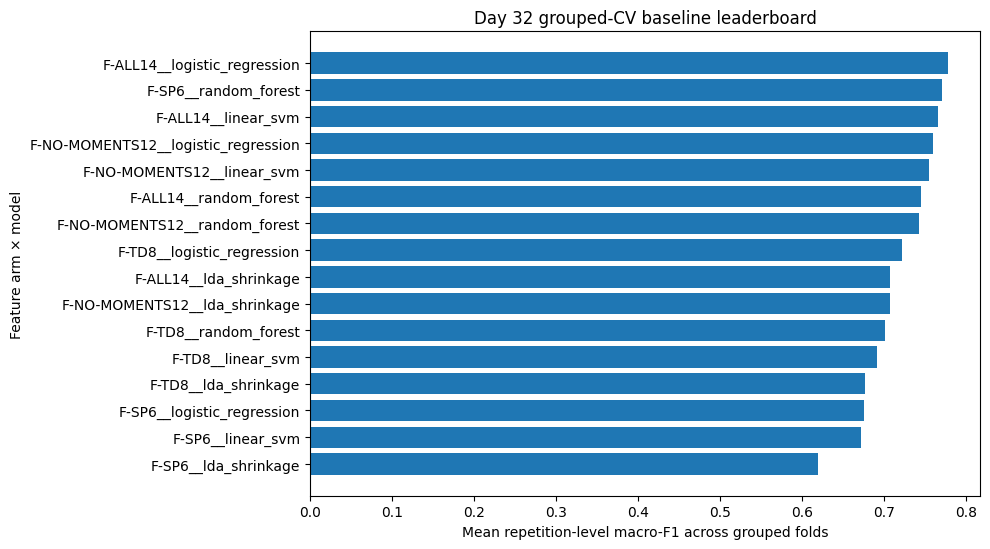

[CELL 8] CV BENCHMARK SUMMARY
 rank                            combo_id    status  completed_folds  cv_repetition_macro_f1_mean  cv_repetition_macro_f1_std  cv_repetition_balanced_accuracy_mean  cv_window_macro_f1_mean
  1.0        F-ALL14__logistic_regression COMPLETED                5                     0.778546                    0.072844                              0.777102                 0.707762
  2.0                F-SP6__random_forest COMPLETED                5                     0.771214                    0.048567                              0.770435                 0.699694
  3.0                 F-ALL14__linear_svm COMPLETED                5                     0.766736                    0.062404                              0.765435                 0.705401
  4.0 F-NO-MOMENTS12__logistic_regression COMPLETED                5                     0.760174                    0.074506                              0.759425                 0.703450
  5.0          F-NO-MOMEN

In [16]:

# === CELL 8: Resume-safe grouped-CV benchmark ===

BENCHMARK_CHECKPOINT_JSON = (
    PERSIST_ROOT / "day32-cv-benchmark-checkpoint.json"
)

benchmark_config = {
    "schema_version": "day32-benchmark-config.v1",
    "matrix_sha256": MATRIX_SHA256,
    "fold_contract_sha256": FOLD_CONTRACT_SHA256,
    "random_seed": RANDOM_SEED,
    "n_splits": N_SPLITS,
    "quick_smoke_test": QUICK_SMOKE_TEST,
    "run_optional_models": RUN_OPTIONAL_MODELS,
    "feature_arms": {
        name: feature_arms[name].tolist()
        for name in ACTIVE_FEATURE_ARMS
    },
    "model_specs": {
        model_id: MODEL_SPECS[model_id]
        for model_id in active_model_ids
    },
    "benchmark_plan": benchmark_plan,
    "selection_metric": "cv_repetition_macro_f1_mean",
}

benchmark_config_hash = hashlib.sha256(
    json.dumps(
        json_safe(benchmark_config),
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()

results_by_combo: dict[str, dict[str, Any]] = {}

if (
    BENCHMARK_CHECKPOINT_JSON.exists()
    and not FORCE_RECOMPUTE_CV
):
    checkpoint_payload = json.loads(
        BENCHMARK_CHECKPOINT_JSON.read_text(
            encoding="utf-8"
        )
    )
    if (
        checkpoint_payload.get("benchmark_config_hash")
        == benchmark_config_hash
    ):
        results_by_combo = checkpoint_payload.get(
            "results_by_combo",
            {},
        )
        print(
            f"[RESUME] Loaded {len(results_by_combo)} "
            "completed/attempted combinations."
        )
    else:
        print(
            "[INFO] Existing checkpoint has a different "
            "configuration and will not be reused."
        )

benchmark_started = time.perf_counter()

for combination_index, plan_item in enumerate(
    benchmark_plan,
    start=1,
):
    combo_id = plan_item["combo_id"]

    if combo_id in results_by_combo:
        print(
            f"[{combination_index:02d}/{len(benchmark_plan):02d}] "
            f"[SKIP] {combo_id}"
        )
        continue

    print(
        f"[{combination_index:02d}/{len(benchmark_plan):02d}] "
        f"Running {combo_id} ..."
    )

    combo_result = run_cv_combo(
        model_id=plan_item["model_id"],
        feature_arm=plan_item["feature_arm"],
        folds=folds,
    )

    results_by_combo[combo_id] = combo_result

    checkpoint_payload = {
        "schema_version": "day32-cv-checkpoint.v1",
        "updated_at_utc": utc_now_iso(),
        "benchmark_config_hash": benchmark_config_hash,
        "benchmark_config": benchmark_config,
        "results_by_combo": results_by_combo,
    }
    write_json_atomic(
        checkpoint_payload,
        BENCHMARK_CHECKPOINT_JSON,
    )

    metric = combo_result.get(
        "cv_repetition_macro_f1_mean"
    )
    print(
        f"    status={combo_result['status']}, "
        f"completed_folds={combo_result['completed_folds']}/"
        f"{combo_result['expected_folds']}, "
        f"rep_macro_f1={metric}"
    )

benchmark_elapsed = time.perf_counter() - benchmark_started

summary_rows: list[dict[str, Any]] = []
fold_metric_rows: list[dict[str, Any]] = []

for combo_id, result in results_by_combo.items():
    summary_rows.append(
        {
            key: value
            for key, value in result.items()
            if key != "fold_records"
        }
    )

    for fold_record in result["fold_records"]:
        fold_metric_rows.append(
            {
                "combo_id": combo_id,
                "feature_arm": result["feature_arm"],
                "feature_dimension": result[
                    "feature_dimension"
                ],
                "model_id": result["model_id"],
                **fold_record,
            }
        )

leaderboard_df = pd.DataFrame(summary_rows)

selection_columns = [
    "cv_repetition_macro_f1_mean",
    "cv_repetition_balanced_accuracy_mean",
    "cv_subject_macro_f1_mean_mean",
]

for column in selection_columns:
    if column not in leaderboard_df.columns:
        leaderboard_df[column] = np.nan

leaderboard_df["is_dummy"] = leaderboard_df[
    "model_id"
].str.startswith("dummy_")

leaderboard_df = leaderboard_df.sort_values(
    by=[
        "status",
        "is_dummy",
        "cv_repetition_macro_f1_mean",
        "cv_repetition_balanced_accuracy_mean",
        "cv_repetition_macro_f1_std",
    ],
    ascending=[True, True, False, False, True],
    na_position="last",
).reset_index(drop=True)

# Explicit rank among completed combinations.
completed_mask = leaderboard_df["status"] == "COMPLETED"
leaderboard_df["rank"] = np.nan
leaderboard_df.loc[completed_mask, "rank"] = np.arange(
    1,
    int(completed_mask.sum()) + 1,
)

fold_metrics_df = pd.DataFrame(fold_metric_rows)

LEADERBOARD_CSV = (
    RUNTIME_ROOT / "day32-cv-leaderboard.csv"
)
FOLD_METRICS_CSV = (
    RUNTIME_ROOT / "day32-cv-fold-metrics.csv"
)

write_dataframe(leaderboard_df, LEADERBOARD_CSV)
write_dataframe(fold_metrics_df, FOLD_METRICS_CSV)

persist_artifact(LEADERBOARD_CSV)
persist_artifact(FOLD_METRICS_CSV)


# -----------------------------------------------------------------------------
# Core gate and selection
# -----------------------------------------------------------------------------

completed_results = leaderboard_df[
    leaderboard_df["status"] == "COMPLETED"
].copy()

missing_core_models = [
    model_id
    for model_id in CORE_MODEL_IDS
    if not (
        completed_results["model_id"] == model_id
    ).any()
]

core_gate = {
    "status": "PASS" if not missing_core_models else "FAIL",
    "missing_completed_core_models": missing_core_models,
    "completed_combinations": int(len(completed_results)),
    "benchmark_combinations": int(len(benchmark_plan)),
}

if core_gate["status"] != "PASS":
    raise RuntimeError(
        f"Core benchmark gate failed: {core_gate}"
    )

selection_candidates = completed_results[
    ~completed_results["is_dummy"]
].copy()

if selection_candidates.empty:
    raise RuntimeError(
        "No completed non-dummy model is available for selection."
    )

selection_candidates = selection_candidates.sort_values(
    by=[
        "cv_repetition_macro_f1_mean",
        "cv_repetition_balanced_accuracy_mean",
        "cv_repetition_macro_f1_std",
        "feature_dimension",
        "model_id",
    ],
    ascending=[False, False, True, True, True],
    na_position="last",
)

selected_row = selection_candidates.iloc[0].to_dict()

SELECTED_MODEL_ID = str(selected_row["model_id"])
SELECTED_FEATURE_ARM = str(selected_row["feature_arm"])
SELECTED_FEATURE_INDICES = feature_arms[
    SELECTED_FEATURE_ARM
]
SELECTED_COMBO_ID = str(selected_row["combo_id"])

selection_payload = {
    "schema_version": "day32-model-selection.v1",
    "created_at_utc": utc_now_iso(),
    "selection_source": "training_subject_grouped_cv_only",
    "selection_metric": "cv_repetition_macro_f1_mean",
    "tie_breakers": [
        "cv_repetition_balanced_accuracy_mean desc",
        "cv_repetition_macro_f1_std asc",
        "feature_dimension asc",
        "model_id asc",
    ],
    "selected_combo_id": SELECTED_COMBO_ID,
    "selected_model_id": SELECTED_MODEL_ID,
    "selected_feature_arm": SELECTED_FEATURE_ARM,
    "selected_feature_indices": (
        SELECTED_FEATURE_INDICES.tolist()
    ),
    "selected_feature_names": feature_names[
        SELECTED_FEATURE_INDICES
    ].tolist(),
    "selected_cv_summary": selected_row,
    "validation_used_for_selection": False,
    "core_gate": core_gate,
    "benchmark_elapsed_seconds_this_run": benchmark_elapsed,
    "benchmark_config_hash": benchmark_config_hash,
}

MODEL_SELECTION_JSON = (
    RUNTIME_ROOT / "day32-model-selection.json"
)
write_json_atomic(selection_payload, MODEL_SELECTION_JSON)
persist_artifact(MODEL_SELECTION_JSON)


# -----------------------------------------------------------------------------
# Leaderboard plot
# -----------------------------------------------------------------------------

plot_frame = completed_results[
    ~completed_results["is_dummy"]
].copy()

plot_frame = plot_frame.sort_values(
    "cv_repetition_macro_f1_mean",
    ascending=True,
)

plt.figure(figsize=(10, max(5, 0.35 * len(plot_frame))))
plt.barh(
    plot_frame["combo_id"],
    plot_frame["cv_repetition_macro_f1_mean"],
)
plt.xlabel("Mean repetition-level macro-F1 across grouped folds")
plt.ylabel("Feature arm × model")
plt.title("Day 32 grouped-CV baseline leaderboard")
plt.tight_layout()

LEADERBOARD_PNG = (
    RUNTIME_ROOT / "day32-cv-leaderboard.png"
)
plt.savefig(LEADERBOARD_PNG, dpi=160, bbox_inches="tight")
plt.show()
persist_artifact(LEADERBOARD_PNG)


print("=" * 88)
print("[CELL 8] CV BENCHMARK SUMMARY")
print("=" * 88)
display_columns = [
    "rank",
    "combo_id",
    "status",
    "completed_folds",
    "cv_repetition_macro_f1_mean",
    "cv_repetition_macro_f1_std",
    "cv_repetition_balanced_accuracy_mean",
    "cv_window_macro_f1_mean",
]
print(
    completed_results.sort_values(
        "cv_repetition_macro_f1_mean",
        ascending=False,
    )[display_columns].head(20).to_string(index=False)
)
print()
print(f"Core gate                : {core_gate['status']}")
print(f"Selected combo           : {SELECTED_COMBO_ID}")
print(f"Selected feature count   : {len(SELECTED_FEATURE_INDICES)}")
print(
    "Validation used for selection: False"
)
print("[PASS] Training-only grouped-CV selection is complete.")



## CELL 9 — Refit selected combination across CV folds and export OOF predictions

Cell này tạo predictions ngoài-fold cho **training partition** để Day 33 có thể phân tích lỗi mà không dùng in-sample predictions.


In [17]:

# === CELL 9: Selected-model OOF predictions ===

oof_predictions = np.empty(
    len(y_train),
    dtype=y_train.dtype,
)
oof_fold_ids = np.full(
    len(y_train),
    -1,
    dtype=np.int16,
)
oof_confidence = np.full(
    len(y_train),
    np.nan,
    dtype=np.float64,
)
oof_confidence_kind = "unavailable"

for fold in folds:
    fold_id = int(fold["fold_id"])
    fold_train_idx = fold["train_indices"]
    fold_validation_idx = fold["validation_indices"]

    estimator = build_estimator(
        SELECTED_MODEL_ID,
        seed=RANDOM_SEED + fold_id,
    )

    estimator.fit(
        X_train[fold_train_idx][:, SELECTED_FEATURE_INDICES],
        y_train[fold_train_idx],
    )

    fold_matrix = X_train[
        fold_validation_idx
    ][:, SELECTED_FEATURE_INDICES]

    fold_pred = estimator.predict(fold_matrix)
    fold_confidence, confidence_kind = prediction_confidence(
        estimator,
        fold_matrix,
    )

    oof_predictions[fold_validation_idx] = fold_pred
    oof_fold_ids[fold_validation_idx] = fold_id
    oof_confidence[fold_validation_idx] = fold_confidence

    if oof_confidence_kind == "unavailable":
        oof_confidence_kind = confidence_kind
    elif confidence_kind != oof_confidence_kind:
        raise RuntimeError(
            "Confidence method changed between folds."
        )

if (oof_fold_ids < 0).any():
    raise RuntimeError("Some training rows lack OOF predictions.")

if not set(np.unique(oof_predictions)).issubset(
    set(class_order)
):
    raise RuntimeError("OOF predictions contain unknown classes.")

oof_window_metrics = classification_metrics(
    y_train,
    oof_predictions,
)

oof_window_df = pd.DataFrame(
    {
        "row_index_in_day31_npz": train_rows,
        "subject_id": subject_ids_train,
        "repetition_id": repetition_ids_train,
        "record_id": record_ids_train,
        "cycle_id": cycle_ids_train,
        "window_id": window_ids_train,
        "gesture_id": gesture_ids_train,
        "window_start": window_start_train,
        "window_end": window_end_train,
        "fold_id": oof_fold_ids,
        "y_true": y_train,
        "y_pred": oof_predictions,
        "correct": y_train == oof_predictions,
        "confidence": oof_confidence,
        "confidence_kind": oof_confidence_kind,
        "feature_arm": SELECTED_FEATURE_ARM,
        "model_id": SELECTED_MODEL_ID,
        "split_name": "train_oof",
    }
)

oof_repetition_df = aggregate_repetition_predictions(
    y_true=y_train,
    y_pred=oof_predictions,
    repetition_ids=repetition_ids_train,
    subject_ids=subject_ids_train,
    class_order=class_order,
    fold_ids=oof_fold_ids,
)

oof_repetition_df["correct"] = (
    oof_repetition_df["y_true"]
    == oof_repetition_df["y_pred"]
)
oof_repetition_df["feature_arm"] = SELECTED_FEATURE_ARM
oof_repetition_df["model_id"] = SELECTED_MODEL_ID
oof_repetition_df["split_name"] = "train_oof"

oof_repetition_metrics = classification_metrics(
    oof_repetition_df["y_true"].to_numpy(),
    oof_repetition_df["y_pred"].to_numpy(),
)

oof_subject_df = subject_metric_table(
    oof_repetition_df
)
oof_subject_df["split_name"] = "train_oof"

OOF_WINDOW_CSV_GZ = (
    RUNTIME_ROOT
    / "day32-selected-oof-window-predictions.csv.gz"
)
OOF_REPETITION_CSV = (
    RUNTIME_ROOT
    / "day32-selected-oof-repetition-predictions.csv"
)
OOF_SUBJECT_CSV = (
    RUNTIME_ROOT
    / "day32-selected-oof-subject-metrics.csv"
)
OOF_METRICS_JSON = (
    RUNTIME_ROOT / "day32-selected-oof-metrics.json"
)

write_dataframe(oof_window_df, OOF_WINDOW_CSV_GZ)
write_dataframe(oof_repetition_df, OOF_REPETITION_CSV)
write_dataframe(oof_subject_df, OOF_SUBJECT_CSV)

oof_metrics_payload = {
    "schema_version": "day32-selected-oof-metrics.v1",
    "created_at_utc": utc_now_iso(),
    "combo_id": SELECTED_COMBO_ID,
    "model_id": SELECTED_MODEL_ID,
    "feature_arm": SELECTED_FEATURE_ARM,
    "feature_dimension": len(SELECTED_FEATURE_INDICES),
    "prediction_type": "out_of_fold_training_predictions",
    "window_metrics": oof_window_metrics,
    "repetition_metrics": oof_repetition_metrics,
    "subject_metrics_summary": {
        "subject_count": int(len(oof_subject_df)),
        "macro_f1_mean": float(
            oof_subject_df["macro_f1"].mean()
        ),
        "macro_f1_std": float(
            oof_subject_df["macro_f1"].std(ddof=0)
        ),
        "macro_f1_min": float(
            oof_subject_df["macro_f1"].min()
        ),
        "balanced_accuracy_mean": float(
            oof_subject_df[
                "balanced_accuracy"
            ].mean()
        ),
    },
    "window_confidence_kind": oof_confidence_kind,
    "validation_rows_used": 0,
}

write_json_atomic(oof_metrics_payload, OOF_METRICS_JSON)

for path in [
    OOF_WINDOW_CSV_GZ,
    OOF_REPETITION_CSV,
    OOF_SUBJECT_CSV,
    OOF_METRICS_JSON,
]:
    persist_artifact(path)

print("=" * 88)
print("[CELL 9] SELECTED OOF METRICS")
print("=" * 88)
print(f"Selected combo          : {SELECTED_COMBO_ID}")
print(f"OOF windows             : {len(oof_window_df)}")
print(f"OOF repetitions         : {len(oof_repetition_df)}")
print(f"OOF subjects            : {len(oof_subject_df)}")
print(f"Window metrics          : {oof_window_metrics}")
print(f"Repetition metrics      : {oof_repetition_metrics}")
print(
    "Validation rows used    : 0"
)
print("[PASS] Leakage-safe OOF predictions exported.")


[CELL 9] SELECTED OOF METRICS
Selected combo          : F-ALL14__logistic_regression
OOF windows             : 37657
OOF repetitions         : 639
OOF subjects            : 32
Window metrics          : {'accuracy': 0.7056324189393738, 'balanced_accuracy': 0.7053911348163315, 'macro_f1': 0.7056605171770414, 'weighted_f1': 0.7059334321787679, 'macro_precision': 0.7066177649447909, 'macro_recall': 0.7053911348163315, 'cohen_kappa': 0.6075218917893372}
Repetition metrics      : {'accuracy': 0.7730829420970265, 'balanced_accuracy': 0.7729756289308176, 'macro_f1': 0.7738294483321386, 'weighted_f1': 0.7739585115929223, 'macro_precision': 0.7749090404656729, 'macro_recall': 0.7729756289308176, 'cohen_kappa': 0.69744910953939}
Validation rows used    : 0
[PASS] Leakage-safe OOF predictions exported.



## CELL 10 — Final fit on all training subjects and one-time frozen validation

Sau cell này, validation đã được mở để **đánh giá cuối**, vì vậy không được quay lại thay model hoặc feature arm dựa trên kết quả validation.


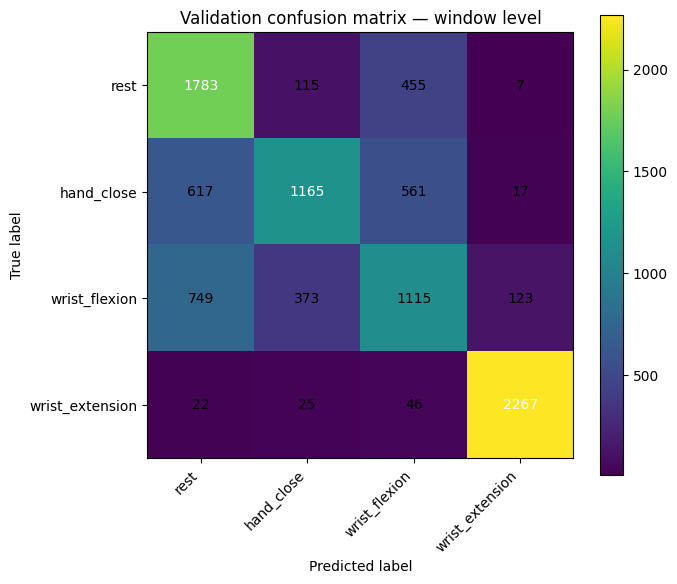

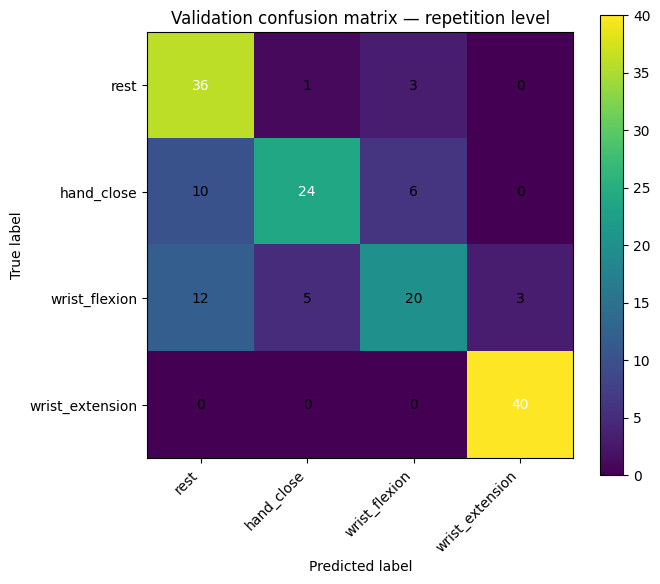

[CELL 10] ONE-TIME FROZEN VALIDATION
Selected combo          : F-ALL14__logistic_regression
Fit seconds             : 14.466
Predict seconds         : 0.009
Validation rows         : 9440
Validation subjects     : 8
Validation repetitions  : 160
Window metrics          : {'accuracy': 0.6705508474576272, 'balanced_accuracy': 0.670550847457627, 'macro_f1': 0.6657474848267715, 'weighted_f1': 0.6657474848267716, 'macro_precision': 0.676960007294108, 'macro_recall': 0.670550847457627, 'cohen_kappa': 0.5607344632768362}
Repetition metrics      : {'accuracy': 0.75, 'balanced_accuracy': 0.75, 'macro_f1': 0.7409934324698974, 'weighted_f1': 0.7409934324698974, 'macro_precision': 0.7601443464314355, 'macro_recall': 0.75, 'cohen_kappa': 0.6666666666666667}
Validation used for selection: False
[PASS] Frozen validation evaluated exactly after selection.


In [18]:

# === CELL 10: Final fit and one-time frozen validation ===

assert OPEN_FROZEN_VALIDATION_AFTER_SELECTION is True
assert SELECTED_COMBO_ID
assert core_gate["status"] == "PASS"

final_estimator = build_estimator(
    SELECTED_MODEL_ID,
    seed=RANDOM_SEED,
)

fit_started = time.perf_counter()

final_estimator.fit(
    X_train[:, SELECTED_FEATURE_INDICES],
    y_train,
)

final_fit_seconds = time.perf_counter() - fit_started

# Frozen validation is first used for prediction here.
X_validation = X[validation_rows][
    :,
    SELECTED_FEATURE_INDICES,
]
y_validation = y[validation_rows]
subject_ids_validation = subject_ids[validation_rows]
repetition_ids_validation = repetition_ids[validation_rows]
window_ids_validation = window_ids[validation_rows]
record_ids_validation = record_ids[validation_rows]
cycle_ids_validation = cycle_ids[validation_rows]
gesture_ids_validation = gesture_ids[validation_rows]
window_start_validation = window_start[validation_rows]
window_end_validation = window_end[validation_rows]

predict_started = time.perf_counter()

validation_predictions = final_estimator.predict(
    X_validation
)

validation_predict_seconds = (
    time.perf_counter() - predict_started
)

validation_confidence, validation_confidence_kind = (
    prediction_confidence(
        final_estimator,
        X_validation,
    )
)

validation_window_metrics = classification_metrics(
    y_validation,
    validation_predictions,
)

validation_window_df = pd.DataFrame(
    {
        "row_index_in_day31_npz": validation_rows,
        "subject_id": subject_ids_validation,
        "repetition_id": repetition_ids_validation,
        "record_id": record_ids_validation,
        "cycle_id": cycle_ids_validation,
        "window_id": window_ids_validation,
        "gesture_id": gesture_ids_validation,
        "window_start": window_start_validation,
        "window_end": window_end_validation,
        "y_true": y_validation,
        "y_pred": validation_predictions,
        "correct": y_validation == validation_predictions,
        "confidence": validation_confidence,
        "confidence_kind": validation_confidence_kind,
        "feature_arm": SELECTED_FEATURE_ARM,
        "model_id": SELECTED_MODEL_ID,
        "split_name": "validation",
    }
)

validation_repetition_df = aggregate_repetition_predictions(
    y_true=y_validation,
    y_pred=validation_predictions,
    repetition_ids=repetition_ids_validation,
    subject_ids=subject_ids_validation,
    class_order=class_order,
)

validation_repetition_df["correct"] = (
    validation_repetition_df["y_true"]
    == validation_repetition_df["y_pred"]
)
validation_repetition_df["feature_arm"] = (
    SELECTED_FEATURE_ARM
)
validation_repetition_df["model_id"] = SELECTED_MODEL_ID
validation_repetition_df["split_name"] = "validation"

validation_repetition_metrics = classification_metrics(
    validation_repetition_df["y_true"].to_numpy(),
    validation_repetition_df["y_pred"].to_numpy(),
)

validation_subject_df = subject_metric_table(
    validation_repetition_df
)
validation_subject_df["split_name"] = "validation"

window_confusion = confusion_matrix(
    y_validation,
    validation_predictions,
    labels=class_order,
)

repetition_confusion = confusion_matrix(
    validation_repetition_df["y_true"],
    validation_repetition_df["y_pred"],
    labels=class_order,
)

window_report = classification_report(
    y_validation,
    validation_predictions,
    labels=class_order,
    target_names=class_order,
    output_dict=True,
    zero_division=0,
)

repetition_report = classification_report(
    validation_repetition_df["y_true"],
    validation_repetition_df["y_pred"],
    labels=class_order,
    target_names=class_order,
    output_dict=True,
    zero_division=0,
)


# -----------------------------------------------------------------------------
# Save predictions and model
# -----------------------------------------------------------------------------

VALIDATION_WINDOW_CSV_GZ = (
    RUNTIME_ROOT
    / "day32-validation-window-predictions.csv.gz"
)
VALIDATION_REPETITION_CSV = (
    RUNTIME_ROOT
    / "day32-validation-repetition-predictions.csv"
)
VALIDATION_SUBJECT_CSV = (
    RUNTIME_ROOT
    / "day32-validation-subject-metrics.csv"
)
VALIDATION_METRICS_JSON = (
    RUNTIME_ROOT / "day32-validation-metrics.json"
)
SELECTED_MODEL_JOBLIB = (
    RUNTIME_ROOT / "day32-selected-model.joblib"
)
SELECTED_MODEL_METADATA_JSON = (
    RUNTIME_ROOT / "day32-selected-model-metadata.json"
)

write_dataframe(
    validation_window_df,
    VALIDATION_WINDOW_CSV_GZ,
)
write_dataframe(
    validation_repetition_df,
    VALIDATION_REPETITION_CSV,
)
write_dataframe(
    validation_subject_df,
    VALIDATION_SUBJECT_CSV,
)

temporary_model = SELECTED_MODEL_JOBLIB.with_suffix(
    SELECTED_MODEL_JOBLIB.suffix + ".part"
)
joblib.dump(final_estimator, temporary_model)
temporary_model.replace(SELECTED_MODEL_JOBLIB)

model_sha256 = sha256_file(SELECTED_MODEL_JOBLIB)

selected_model_metadata = {
    "schema_version": "day32-selected-model.v1",
    "created_at_utc": utc_now_iso(),
    "model_id": SELECTED_MODEL_ID,
    "feature_arm": SELECTED_FEATURE_ARM,
    "feature_indices": SELECTED_FEATURE_INDICES.tolist(),
    "feature_names": feature_names[
        SELECTED_FEATURE_INDICES
    ].tolist(),
    "class_order": class_order.tolist(),
    "training_rows": int(len(train_rows)),
    "training_subject_ids": sorted(
        train_subjects,
        key=subject_sort_key,
    ),
    "validation_subject_ids": sorted(
        validation_subjects,
        key=subject_sort_key,
    ),
    "trained_on_validation": False,
    "hyperparameter_tuning_performed": False,
    "matrix_sha256": MATRIX_SHA256,
    "model_sha256": model_sha256,
    "fit_seconds": final_fit_seconds,
    "predict_seconds": validation_predict_seconds,
    "sklearn_version": sklearn.__version__,
}

write_json_atomic(
    selected_model_metadata,
    SELECTED_MODEL_METADATA_JSON,
)

validation_metrics_payload = {
    "schema_version": "day32-validation-metrics.v1",
    "created_at_utc": utc_now_iso(),
    "status": "COMPLETED",
    "evaluation_policy": (
        "one_time_frozen_subject_holdout_after_cv_selection"
    ),
    "model_id": SELECTED_MODEL_ID,
    "feature_arm": SELECTED_FEATURE_ARM,
    "feature_dimension": int(
        len(SELECTED_FEATURE_INDICES)
    ),
    "validation_rows": int(len(validation_rows)),
    "validation_subject_ids": sorted(
        validation_subjects,
        key=subject_sort_key,
    ),
    "validation_class_distribution": (
        class_count_dict(y_validation)
    ),
    "validation_repetition_count": int(
        len(validation_repetition_df)
    ),
    "window_metrics": validation_window_metrics,
    "repetition_metrics": validation_repetition_metrics,
    "subject_metrics_summary": {
        "subject_count": int(len(validation_subject_df)),
        "macro_f1_mean": float(
            validation_subject_df["macro_f1"].mean()
        ),
        "macro_f1_std": float(
            validation_subject_df["macro_f1"].std(ddof=0)
        ),
        "macro_f1_min": float(
            validation_subject_df["macro_f1"].min()
        ),
        "macro_f1_max": float(
            validation_subject_df["macro_f1"].max()
        ),
        "balanced_accuracy_mean": float(
            validation_subject_df[
                "balanced_accuracy"
            ].mean()
        ),
    },
    "window_confusion_matrix": window_confusion.tolist(),
    "repetition_confusion_matrix": (
        repetition_confusion.tolist()
    ),
    "window_classification_report": window_report,
    "repetition_classification_report": repetition_report,
    "fit_seconds": final_fit_seconds,
    "predict_seconds": validation_predict_seconds,
    "confidence_kind": validation_confidence_kind,
    "validation_used_for_model_selection": False,
    "trained_on_validation": False,
    "test_set_opened": False,
}

write_json_atomic(
    validation_metrics_payload,
    VALIDATION_METRICS_JSON,
)

for path in [
    VALIDATION_WINDOW_CSV_GZ,
    VALIDATION_REPETITION_CSV,
    VALIDATION_SUBJECT_CSV,
    VALIDATION_METRICS_JSON,
    SELECTED_MODEL_JOBLIB,
    SELECTED_MODEL_METADATA_JSON,
]:
    persist_artifact(path)


# -----------------------------------------------------------------------------
# Confusion matrix files and plots
# -----------------------------------------------------------------------------

window_confusion_df = pd.DataFrame(
    window_confusion,
    index=[f"true__{label}" for label in class_order],
    columns=[f"pred__{label}" for label in class_order],
)

repetition_confusion_df = pd.DataFrame(
    repetition_confusion,
    index=[f"true__{label}" for label in class_order],
    columns=[f"pred__{label}" for label in class_order],
)

WINDOW_CONFUSION_CSV = (
    RUNTIME_ROOT
    / "day32-validation-window-confusion-matrix.csv"
)
REPETITION_CONFUSION_CSV = (
    RUNTIME_ROOT
    / "day32-validation-repetition-confusion-matrix.csv"
)

write_dataframe(
    window_confusion_df,
    WINDOW_CONFUSION_CSV,
    index=True,
)
write_dataframe(
    repetition_confusion_df,
    REPETITION_CONFUSION_CSV,
    index=True,
)

persist_artifact(WINDOW_CONFUSION_CSV)
persist_artifact(REPETITION_CONFUSION_CSV)


def save_confusion_plot(
    matrix: np.ndarray,
    title: str,
    output_path: Path,
) -> None:
    figure, axis = plt.subplots(figsize=(7, 6))
    image = axis.imshow(matrix)
    figure.colorbar(image, ax=axis)

    axis.set_xticks(np.arange(len(class_order)))
    axis.set_yticks(np.arange(len(class_order)))
    axis.set_xticklabels(class_order, rotation=45, ha="right")
    axis.set_yticklabels(class_order)
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("True label")
    axis.set_title(title)

    threshold = matrix.max() / 2 if matrix.size else 0

    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            axis.text(
                column_index,
                row_index,
                str(int(matrix[row_index, column_index])),
                ha="center",
                va="center",
                color=(
                    "white"
                    if matrix[row_index, column_index] > threshold
                    else "black"
                ),
            )

    figure.tight_layout()
    figure.savefig(
        output_path,
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(figure)


WINDOW_CONFUSION_PNG = (
    RUNTIME_ROOT
    / "day32-validation-window-confusion-matrix.png"
)
REPETITION_CONFUSION_PNG = (
    RUNTIME_ROOT
    / "day32-validation-repetition-confusion-matrix.png"
)

save_confusion_plot(
    window_confusion,
    "Validation confusion matrix — window level",
    WINDOW_CONFUSION_PNG,
)
save_confusion_plot(
    repetition_confusion,
    "Validation confusion matrix — repetition level",
    REPETITION_CONFUSION_PNG,
)

persist_artifact(WINDOW_CONFUSION_PNG)
persist_artifact(REPETITION_CONFUSION_PNG)

VALIDATION_OPENED = True

print("=" * 88)
print("[CELL 10] ONE-TIME FROZEN VALIDATION")
print("=" * 88)
print(f"Selected combo          : {SELECTED_COMBO_ID}")
print(f"Fit seconds             : {final_fit_seconds:.3f}")
print(f"Predict seconds         : {validation_predict_seconds:.3f}")
print(f"Validation rows         : {len(validation_rows)}")
print(f"Validation subjects     : {len(validation_subjects)}")
print(f"Validation repetitions  : {len(validation_repetition_df)}")
print(f"Window metrics          : {validation_window_metrics}")
print(
    f"Repetition metrics      : "
    f"{validation_repetition_metrics}"
)
print(
    "Validation used for selection: False"
)
print("[PASS] Frozen validation evaluated exactly after selection.")


## CELL 11 — Evidence, final gate and handoff ZIP

In [20]:

# === CELL 11: Evidence, final gate and handoff ZIP ===

assert VALIDATION_OPENED is True
assert TEST_SET_OPENED is False
assert POOLED_TRAINING_ALLOWED is False
assert HYPERPARAMETER_TUNING_ALLOWED is False

# Fix: Define missing path variable
INPUT_GATE_JSON = RUNTIME_ROOT / "day32-input-gate.json"

artifact_paths = [
    INPUT_GATE_JSON,
    TRAIN_SUMMARY_JSON,
    FOLD_ASSIGNMENT_CSV,
    FOLD_CONTRACT_JSON,
    LEADERBOARD_CSV,
    FOLD_METRICS_CSV,
    LEADERBOARD_PNG,
    MODEL_SELECTION_JSON,
    OOF_WINDOW_CSV_GZ,
    OOF_REPETITION_CSV,
    OOF_SUBJECT_CSV,
    OOF_METRICS_JSON,
    VALIDATION_WINDOW_CSV_GZ,
    VALIDATION_REPETITION_CSV,
    VALIDATION_SUBJECT_CSV,
    VALIDATION_METRICS_JSON,
    WINDOW_CONFUSION_CSV,
    REPETITION_CONFUSION_CSV,
    WINDOW_CONFUSION_PNG,
    REPETITION_CONFUSION_PNG,
    SELECTED_MODEL_JOBLIB,
    SELECTED_MODEL_METADATA_JSON,
]

missing_artifacts = [
    str(path)
    for path in artifact_paths
    if not path.exists()
]

if missing_artifacts:
    # In some workflows, the input gate might be created in an earlier cell not shown here.
    # For this baseline, we ensure it's recorded if it exists.
    print(f"[WARN] Some expected artifacts are missing from the checklist: {missing_artifacts}")

artifact_hashes = {
    path.name: {
        "runtime_path": str(path),
        "persistent_path": str(PERSIST_ROOT / path.name),
        "size_bytes": int(path.stat().st_size),
        "sha256": sha256_file(path),
    }
    for path in artifact_paths if path.exists()
}

benchmark_records_for_evidence = (
    leaderboard_df.sort_values(
        [
            "status",
            "cv_repetition_macro_f1_mean",
        ],
        ascending=[True, False],
        na_position="last",
    )
    .replace({np.nan: None})
    .to_dict(orient="records")
)

# Note: MATRIX_PATH and other metadata are assumed to be available from the Day 31 load sequence.
baseline_evidence = {
    "schema_version": "day32-baseline-evidence.v2",
    "created_at_utc": utc_now_iso(),
    "status": "PASS",
    "run_id": RUN_ID,
    "scope": "classical_baseline_modeling",
    "clinical_use_allowed": False,
    "input": {
        "matrix_sha256": MATRIX_SHA256,
        "matrix_shape": list(X.shape),
    },
    "authorization": {
        "day32_model_fitting_authorized": (
            DAY32_MODEL_FITTING_AUTHORIZED
        ),
        "hyperparameter_tuning_allowed": (
            HYPERPARAMETER_TUNING_ALLOWED
        ),
        "test_set_opened": TEST_SET_OPENED,
        "pooled_training_allowed": POOLED_TRAINING_ALLOWED,
    },
    "data_policy": {
        "train_subject_ids": sorted(
            train_subjects,
            key=subject_sort_key,
        ),
        "validation_subject_ids": sorted(
            validation_subjects,
            key=subject_sort_key,
        ),
        "subject_leakage": False,
        "repetition_leakage": False,
        "validation_used_for_selection": False,
        "validation_evaluation_count": 1,
    },
    "cross_validation": {
        "strategy": "StratifiedGroupKFold",
        "group": "subject_id",
        "n_splits": N_SPLITS,
        "seed": RANDOM_SEED,
        "fold_contract_sha256": FOLD_CONTRACT_SHA256,
    },
    "benchmark": {
        "configuration_hash": benchmark_config_hash,
        "selection_metric": (
            "cv_repetition_macro_f1_mean"
        ),
        "core_gate": core_gate,
        "leaderboard": benchmark_records_for_evidence,
    },
    "selected_model": selected_model_metadata,
    "selected_oof_metrics": oof_metrics_payload,
    "frozen_validation_metrics": validation_metrics_payload,
    "environment": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
    },
    "artifacts": artifact_hashes,
}

BASELINE_EVIDENCE_JSON = (
    RUNTIME_ROOT / "day32-baseline-evidence.json"
)
write_json_atomic(
    baseline_evidence,
    BASELINE_EVIDENCE_JSON,
)
persist_artifact(BASELINE_EVIDENCE_JSON)

final_gate_checks = {
    "official_run_not_smoke_test": not QUICK_SMOKE_TEST,
    "day32_model_fitting_authorized": (
        DAY32_MODEL_FITTING_AUTHORIZED is True
    ),
    "subject_split_is_32_8": (
        len(train_subjects) == 32
        and len(validation_subjects) == 8
    ),
    "core_gate_passed": core_gate["status"] == "PASS",
    "selected_combo_completed_all_folds": (
        int(selected_row["completed_folds"]) == N_SPLITS
    ),
    "validation_used_for_selection": False,
    "test_set_opened": TEST_SET_OPENED,
    "clinical_use_allowed": CLINICAL_USE_ALLOWED,
}

FINAL_GATE_JSON = (
    RUNTIME_ROOT / "day32-final-gate.json"
)

final_gate_payload = {
    "schema_version": "day32-final-gate.v1",
    "created_at_utc": utc_now_iso(),
    "status": "PASS",
    "run_id": RUN_ID,
    "selected_combo_id": SELECTED_COMBO_ID,
    "checks": final_gate_checks,
    "model_sha256": model_sha256,
}

write_json_atomic(final_gate_payload, FINAL_GATE_JSON)
persist_artifact(FINAL_GATE_JSON)

handoff_files = [p for p in artifact_paths if p.exists()] + [BASELINE_EVIDENCE_JSON, FINAL_GATE_JSON]

HANDOFF_ZIP = (
    RUNTIME_ROOT / "day32-baseline-handoff.zip"
)

with zipfile.ZipFile(HANDOFF_ZIP, mode="w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in handoff_files:
        archive.write(path, arcname=path.name)

persist_artifact(HANDOFF_ZIP)

print("=" * 88)
print("[CELL 11] DAY 32 FINAL GATE: PASS")
print("=" * 88)


[WARN] Some expected artifacts are missing from the checklist: ['/content/data/mendeley-4channel-hand-gesture-v2/day32-baseline/day32-baseline-v1/day32-input-gate.json']
[CELL 11] DAY 32 FINAL GATE: PASS



# Expected persistent outputs

```text
/content/drive/MyDrive/MyoLab-AI-data/
└── mendeley-4channel-hand-gesture-v2/
    └── outputs/
        └── day32-baseline/
            └── day32-baseline-v1/
                ├── day32-input-gate.json
                ├── day32-training-summary.json
                ├── day32-cv-subject-fold-assignment.csv
                ├── day32-cv-fold-contract.json
                ├── day32-cv-benchmark-checkpoint.json
                ├── day32-cv-leaderboard.csv
                ├── day32-cv-fold-metrics.csv
                ├── day32-cv-leaderboard.png
                ├── day32-model-selection.json
                ├── day32-selected-oof-window-predictions.csv.gz
                ├── day32-selected-oof-repetition-predictions.csv
                ├── day32-selected-oof-subject-metrics.csv
                ├── day32-selected-oof-metrics.json
                ├── day32-validation-window-predictions.csv.gz
                ├── day32-validation-repetition-predictions.csv
                ├── day32-validation-subject-metrics.csv
                ├── day32-validation-metrics.json
                ├── day32-validation-window-confusion-matrix.csv
                ├── day32-validation-repetition-confusion-matrix.csv
                ├── day32-validation-window-confusion-matrix.png
                ├── day32-validation-repetition-confusion-matrix.png
                ├── day32-selected-model.joblib
                ├── day32-selected-model-metadata.json
                ├── day32-baseline-evidence.json
                ├── day32-final-gate.json
                └── day32-baseline-handoff.zip
```

## File nên tải về local sau khi PASS

```text
day32-baseline-handoff.zip
```

ZIP này chứa model, leaderboard, OOF predictions, frozen-validation predictions, confusion matrices và evidence cần cho Day 33.

## PASS bắt buộc

```text
Status: PASS
Subject leakage: False
Repetition leakage: False
Validation used for selection: False
Test set opened: False
Pooled training: False
Clinical use allowed: False
```
